<b><font size="6"> **Cars 4 You: Expediting Car Evaluations with ML** </font></b><br><br>

`GROUP 21`

20250413 João Ramos <br>
20250401 Oliver Kain <br>
20250415 Gonçalo Castro <br>
20250344 Mehmet Karaca <br>


In this notebook, we present our approach to predicting car prices using machine learning techniques. We will cover all of the typical steps in a machine learning pipeline, including data preprocessing, feature engineering, model selection, hyperparameter tuning, and evaluation.

### <font color='#BFD72F'>**Schematic Layout** </font> <a class="anchor">


<img src="images/process_ML.png" alt="Drawing" style="width: 1000px;"/>

### <font color='#BFD72F'>**Methodology** </font> <a class="anchor" id='toc'></a> 

- [1. Import libraries](#1) 
- [2. Data Integration](#2) 
- [3. Data Exploration](#3)
    - [3.1 Insights on the whole Dataset](#3_1)
        - [3.1.1 Schema Overview](#3_1_1)
        - [3.1.2 Descriptive Statistics (Numerical & Categorical)](#3_1_2)
        - [3.1.3 Missing Values](#3_1_3)
        - [3.1.4 Duplicates](#3_1_4)
        - [3.1.5 Feature Distributions](#3_1_5)
        - [3.1.6 Potential Outliers](#3_1_6)
        - [3.1.7 Categorical Overview](#3_1_7)
        - [3.1.8 Correlation Analysis (Numerical Features)](#3_1_8)
        - [3.1.9 Bivariate Relationships w.r.t Target (price)](#3_1_9)
        - [3.1.10 Data Quality Checks](#3_1_10)
        - [3.1.11 Negative Values Analysis](#3_1_11)
            - [3.1.11.1 Negative Tax Values](#3_1_11_1)
            - [3.1.11.2 Negative Mileage Values](#3_1_11_2)
            - [3.1.11.3 Negative previousOwners Values](#3_1_11_3) 
        - [3.1.12 Non-Integer Year Values](#3_1_12)
        - [3.1.13 Key Takeaways for the Data Preparation Phase](#3_1_13)
- [4. Data Preparation](#4) 
    - [4.1 Data Partition](#4_1)
    - [4.2 Type Casting](#4_2)
    - [4.3 Mapping and Normalization Of Features Values](#4_3)
        - [4.3.1 `Transmission` Normalization and Mapping](#4_3_1)
        - [4.3.2 `Fuel Type` Normalization and Mapping](#4_3_2)
        - [4.3.3 `Model` Normalization and Mapping](#4_3_3)
        - [4.3.4 `Brand` Normalization and Mapping](#4_3_4)
    - [4.4 Handling Invalid Outliers](#4_4)
        - [4.4.1 `Year` after 2020 and Non-Integer Values](#4_4_1)
        - [4.4.2 `Engine Size` below 1.0L and above 6.2L](#4_4_2)
        - [4.4.3 Other process errors found in data exploration](#4_4_3)
    - [4.5 Data Imputation](#4_5)
        - [4.5.1 Imputation of Categorical Features](#4_5_1)
            - [4.5.1.1 `Transmission` Imputation](#4_5_1_1)
            - [4.5.1.2 `Fuel Type` Imputation](#4_5_1_2)
            - [4.5.1.3 `Brand` Imputation](#4_5_1_3)
            - [4.5.1.4 `Model` Imputation](#4_5_1_4)
        - [4.5.2 Imputation of Numerical Features](#4_5_2)
            - [4.5.2.1 `Mileage` Imputation](#4_5_2_1)
            - [4.5.2.2 `Year` Imputation](#4_5_2_2)
            - [4.5.2.3 `Mpg` Imputation](#4_5_2_3)
            - [4.5.2.4 `Previous Owners` Imputation](#4_5_2_4)
            - [4.5.2.5 `Tax` Imputation](#4_5_2_5)
            - [4.5.2.6 `Engine Size` Imputation](#4_5_2_6)
        - [4.5.3 Pipeline Definition](#4_5_3)
            - [4.5.3.1 Encoding Pipelines](#4_5_3_1)
            - [4.5.3.2 Data Imputation Pipeline](#4_5_3_2)
    - [4.6 Feature Engineering](#4_6)
    - [4.7 Encoding](#4_7)
    - [4.8 Scaling](#4_8)
- [5. Feature Selection](#5)
- [6. Modeling and Assessment](#6)
    - [ 6.1 Model Selection](#6_1)
    - [ 6.2 Model Optimization](#6_2)
- [7. Deployment](#7)     

<!-- <a class="anchor" id="1">

# **1. Import libraries**

[Back to TOC](#toc)
</a>

To embark on this project, it is essential to import the necessary libraries which play a pivotal role in efficient data management and predictive model development. 

This approach employed the use of NumPy and Pandas for the manipulation of data, and Plotly for the creation of interactive visualisations. Statistical tests were conducted using SciPy, while the preprocessing and modelling were dependent on scikit-learn, including tools for imputation, encoding, scaling, and a variety of machine learning algorithms. Performance evaluation was carried out using F1-score metrics. -->

In [56]:
import os, re, math, warnings
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from datetime import datetime
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.base import clone, BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingRegressor, StackingRegressor, AdaBoostRegressor, GradientBoostingRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler, MinMaxScaler, TargetEncoder, KBinsDiscretizer, PowerTransformer
from sklearn.linear_model import LinearRegression, LassoCV, ElasticNet, BayesianRidge, RidgeCV, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFECV, VarianceThreshold, SelectFromModel
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from dotenv import load_dotenv
from dataclasses import dataclass
from collections import defaultdict
import time

pd.set_option("display.width", 160)
pd.set_option("mode.copy_on_write", True)
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42  # for reproducibility of any sampling

In [57]:
def is_safe_group(g: pd.DataFrame, compare_cols: list) -> bool:
    """
    Returns True if the rows in this group can be considered "safe duplicates".

    A group is "safe" when, for every column we compare, all non-missing values
    agree with each other. Differences caused only by missing values (NaNs) are allowed.
    """
    for col in compare_cols:
        vals = g[col].dropna()
        if vals.nunique() > 1:
            return False
    return True

In [58]:
def to_int_series(s):
    return pd.to_numeric(s, errors="coerce").round().astype("Int64")

def to_float_series(s):
    return pd.to_numeric(s, errors="coerce").astype(float)


def conversion_dtypes(obj):
    # --- Handle Series input (this is your y column) ---
    if isinstance(obj, pd.Series):
        s = obj.copy()

        # Clean string NaN-like values
        s = (
            s.astype(object)
             .astype(str)
             .str.strip()
             .replace({
                 "nan": np.nan, "NaN": np.nan, "None": np.nan, "NA": np.nan,
                 "<NA>": np.nan, "": np.nan, "null": np.nan, "NULL": np.nan
             })
        )

        # Convert to float (price)
        s = pd.to_numeric(s, errors="coerce").astype(float)
        return s

    # --- Handle DataFrame input ---
    df = obj.copy()
    nan_report = {}

    num_cols = ["price", "mileage", "engineSize", "mpg", "tax", "year", "previousOwners"]

    # --- NUMERIC PROCESSING ---
    for col in num_cols:
        if col in df.columns:

            before = df[col].isna().sum()

            df[col] = (
                df[col]
                .astype(object)
                .astype(str)
                .str.strip()
                .replace({
                    "nan": np.nan, "NaN": np.nan, "None": np.nan,
                    "NA": np.nan, "<NA>": np.nan, "": np.nan,
                    "null": np.nan, "NULL": np.nan,
                })
            )

            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

            after = df[col].isna().sum()
            if after > before:
                nan_report[col] = after - before


    # --- OBJECT PROCESSING ---
    for col in df.select_dtypes(include=["object", "string"]).columns:
        before = df[col].isna().sum()

        df[col] = (
            df[col]
            .astype(object)
            .astype(str)
            .str.strip()
            .replace({
                "nan": np.nan, "NaN": np.nan, "None": np.nan,
                "NA": np.nan, "<NA>": np.nan, "": np.nan,
                "null": np.nan, "NULL": np.nan,
            })
        )

        after = df[col].isna().sum()
        if after > before:
            nan_report[col] = after - before


    if nan_report:
        print("Columns where casting/cleaning created new NaNs:")
        for col, n in nan_report.items():
            print(f"  - {col}: +{n} NaNs")

    return df

In [59]:
def normalize_transmission(value: str):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = re.sub(r"[.,_]", " ", value)
    value = " ".join(value.split())
    return value

def apply_transmission_mapping(df: pd.DataFrame,
                               mapping_path: str = "../mapping/transmission_mapping.json",
                               col: str = "transmission") -> pd.DataFrame:
    # load + normalize mapping keys
    with open(mapping_path, "r", encoding="utf-8") as f:
        raw_map = json.load(f)

    trans_canon = {normalize_transmission(k): v for k, v in raw_map.items()}

    # normalize column
    norm_col = f"{col}_norm"
    df[norm_col] = df[col].apply(normalize_transmission)

    # map
    df[col] = df[norm_col].map(trans_canon)
    
    df[col] = df[col].fillna("Unknown")

    # check unmapped
    unmapped = (
        df.loc[df[col].isna(), norm_col]
          .dropna()
          .unique()
    )
    if len(unmapped) > 0:
        print(f"[WARN] Unmapped {col} values:")
        for v in unmapped:
            print("  -", repr(v))

    # drop helper
    df.drop(columns=[norm_col], inplace=True)

    return df


In [60]:
def normalize_fuel(value: str):
    """Normalize raw fuelType text before mapping."""
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = re.sub(r"[.,-_]", " ", value)  # unify separators
    value = " ".join(value.split())        # collapse spaces
    return value

def apply_fuel_mapping(
    df: pd.DataFrame,
    mapping_path: str = "../mapping/fueltype_mapping.json",
    col: str = "fuelType"
) -> pd.DataFrame:
    # load + normalize mapping keys
    with open(mapping_path, "r", encoding="utf-8") as f:
        raw_fuel_map = json.load(f)

    FUEL_CANON = {normalize_fuel(k): v for k, v in raw_fuel_map.items()}

    norm_col = f"{col}_norm"
    df[norm_col] = df[col].apply(normalize_fuel)

    # map
    df[col] = df[norm_col].map(FUEL_CANON)
    
    df[col] = df[col].fillna("Unknown")


    # report unmapped
    unmapped = (
        df.loc[df[col].isna(), norm_col]
          .dropna()
          .unique()
    )
    if len(unmapped) > 0:
        print(f"[WARN] Unmapped {col} values (add to JSON):")
        for v in unmapped:
            print("  -", repr(v))

    # drop helper
    df.drop(columns=[norm_col], inplace=True)

    return df

In [61]:
def norm_model(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    s = re.sub(r"[.,\-_ ]+", "", s)
    return s

def apply_model_mapping(
    df: pd.DataFrame,
    mapping_path: str = "../mapping/modelname_mapping.json",
    col: str = "model"
) -> pd.DataFrame:
    # load JSON
    with open(mapping_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    raw_aliases = cfg["aliases"]
    regex_rules = cfg.get("regex_rules", [])

    # normalize alias keys
    ALIASES = {norm_model(k): v for k, v in raw_aliases.items()}

    def apply_regex_first(val: str) -> str:
        for rule in regex_rules:
            pat = rule["pattern"]
            repl = rule["replace"]
            m = re.fullmatch(pat, val)
            if m:
                return m.expand(repl)
        return val

    if col not in df.columns:
        print(f"[INFO] column '{col}' not in df, skipping.")
        return df


    # normalize incoming values
    df[f"{col}_norm"] = df[col].apply(norm_model)

    # map
    def map_model(norm_val):
        if pd.isna(norm_val):
            return np.nan
        norm_val = apply_regex_first(norm_val)
        return ALIASES.get(norm_val, np.nan)

    df[f"{col}_mapped"] = df[f"{col}_norm"].apply(map_model)

    # overwrite with mapped
    df[col] = df[f"{col}_mapped"]
    
    df[col] = df[col].replace({pd.NA: np.nan})

    # everything that had a value (norm not NA) but no mapping -> set to NA
    mask_unmapped = df[col].isna() & df[f"{col}_norm"].notna()
    df.loc[mask_unmapped, col] = "Unknown"

    # clean up
    df.drop(columns=[f"{col}_norm", f"{col}_mapped"], inplace=True)

    return df

In [62]:
def normalize_brand(value: str):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    value = re.sub(r"[.,-_]", " ", value)
    value = " ".join(value.split())
    return value

def apply_brand_mapping(
    df: pd.DataFrame,
    mapping_path: str = "../mapping/brandname_mapping.json",
    col: str = "Brand"
) -> pd.DataFrame:
    if col not in df.columns:
        print(f"[INFO] Column '{col}' not found.")
        return df

    # load mapping
    with open(mapping_path, "r", encoding="utf-8") as f:
        raw_brand_map = json.load(f)

    # normalize mapping keys
    BRAND_CANON = {normalize_brand(k): v for k, v in raw_brand_map.items()}

    was_nan_before = df[col].isna()

    # normalize column
    norm_col = f"{col}_norm"
    df[norm_col] = df[col].apply(normalize_brand)

    # map
    mapped = df[norm_col].map(BRAND_CANON)
    
    df[col] = df[col].fillna("Unknown")

    # keep original where no mapping exists
    clean_col = f"{col}_clean"
    df[clean_col] = np.where(
    mapped.isna(),
    df[col],        # original value
    mapped.astype("object")  # mapped value
    )

    df[clean_col] = df[clean_col].replace({pd.NA: np.nan})

    # detect new NaNs that came from missing mapping
    new_nans_mask = df[clean_col].isna() & (~was_nan_before)
    new_nans_count = new_nans_mask.sum()

    # collect unmapped originals
    unmapped = (
        df.loc[mapped.isna() & (~was_nan_before) & df[norm_col].notna(), norm_col]
          .dropna()
          .unique()
    )

    # replace original
    df[col] = df[clean_col]
    df.drop(columns=[norm_col, clean_col], inplace=True)

    if new_nans_count > 0:
        print(f"[WARN] {new_nans_count} rows became NaN due to missing mapping.")
    if len(unmapped) > 0:
        print("\n[WARN] Unmapped brand values (add to JSON):")
        for v in unmapped:
            print("  -", repr(v))

    return df

In [63]:
def fill_brand_from_model(
    df: pd.DataFrame,
    mapping_path: str = "../mapping/brand_model_mapping.json"
) -> pd.DataFrame:
    """
    Fills df['Brand'] when:
      - Brand is NaN
      - model has a value
      - model exists in the JSON (brand_model_mapping.json)
    """
    # load JSON: {"A1": "Audi", "Golf": "Volkswagen", ...}
    with open(mapping_path, "r", encoding="utf-8") as f:
        model_to_brand = json.load(f)

    # debug before
    before = df["Brand"].isna().sum()

    # rows where Brand is missing but model is present
    mask = df["Brand"].isna() & df["model"].notna()

    # map model -> Brand
    mapped = df.loc[mask, "model"].map(model_to_brand)

    # write back only where we actually found a brand
    fill_mask = mask.copy()
    fill_mask.loc[mask] = mapped.notna()

    df.loc[fill_mask, "Brand"] = mapped[mapped.notna()]

    return df

In [64]:
def mapping_and_normalization(df: pd.DataFrame) -> pd.DataFrame:
    """ Applies mapping and normalization to the given DataFrame."""
    df = apply_fuel_mapping(df)
    df = apply_transmission_mapping(df)
    df = apply_brand_mapping(df) 
    df = apply_model_mapping(df)
    df = fill_brand_from_model(df) # fill missing Brand from model where possible
    return df

In [65]:
def handle_invalid_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # According to the guidelines, we can conclude that paintQuality% is not relevant for our model
    df = df.drop(columns=['paintQuality%'])
    # Based on the previous analysis of the dataset, we concluded that these non-integer values shouldn't just be rounded
    df.loc[df['year'] % 1 != 0, 'year'] = np.nan
    # There are most likely no sign errors in these columns, so we set negative values to NaN in order to be imputed properly later
    df.loc[df['mileage'] < 0, 'mileage'] = np.nan
    # The same applies to the tax column so we set negative values to NaN
    df.loc[df['tax'] < 0, 'tax'] = np.nan
    # The same applies to the mpg column so we just set negative values to NaN in order for them to be properly imputed later
    df.loc[df['mpg'] < 0, 'mpg'] = np.nan
    # The negative previousOwners values are most likely data entry errors so we also set them to NaN
    df.loc[df['previousOwners'] < 0, 'previousOwners'] = np.nan
    # Some mpg values are not realistic given the fuelType of the car, so we filtered the values depending on their fuelType
    # Where these unrealistic values are found, we set them to NaN in order to be imputed properly later
    unusual_mpg_mask = ((df['mpg'] > 150) & (df["fuelType"] == "Electric")) | \
                       ((df['mpg'] < 70) & (df["fuelType"] == "Electric")) | \
                       ((df['mpg'] > 100) & (df["fuelType"] == "Hybrid")) | \
                       ((df['mpg'] < 35) & (df["fuelType"] == "Hybrid")) | \
                       ((df['mpg'] > 80) & (df["fuelType"] != "Hybrid") & (df["fuelType"] != "Electric")) | \
                       ((df['mpg'] < 8) & (df["fuelType"] != "Hybrid") & (df["fuelType"] != "Electric"))
    df.loc[unusual_mpg_mask, 'mpg'] = np.nan
    # The years after 2020 are invalid so we set them to NaN
    df.loc[df['year'] > 2020, 'year'] = np.nan
    # The non-integer previousOwners values are invalid so we set them to NaN
    df.loc[df['previousOwners'] % 1 != 0, 'previousOwners'] = np.nan
    # The other unusual float values are also invalid so we set them to NaN
    df.loc[(df['engineSize']*10) % 1 != 0, 'engineSize'] = np.nan
    df.loc[df['tax'] % 1 != 0, 'tax'] = np.nan
    df.loc[df['mileage'] % 1 != 0, 'mileage'] = np.nan
    df.loc[(df['mpg']*10) % 1 != 0, 'mpg'] = np.nan
    # From our domain knowledge we know that engine sizes below 0.8L and above 6.2L are very unlikely in this dataset
    # so we set these values to NaN
    df.loc[((df['engineSize'] > 6.2) | (df['engineSize'] < 0.8)), 'engineSize'] = np.nan
    # Here we set the 'Unknown' mapped categorical values to NaN in order to be imputed properly later
    # since there was no reliable mapping for these values
    df.loc[df['transmission'] == 'Unknown', 'transmission'] = np.nan
    df.loc[df['fuelType'] == 'Unknown', 'fuelType'] = np.nan
    df.loc[df['Brand'] == 'Unknown', 'Brand'] = np.nan
    df.loc[df['model'] == 'Unknown', 'model'] = np.nan

    return df

In [66]:
def missing_report(X: pd.DataFrame, name: str) -> pd.DataFrame:
    mv = X.isna().sum()
    mv = mv[mv > 0].sort_values(ascending=False)
    if mv.empty:
        print(f"[{name}] No missing values found. (n_rows={len(X)})")
        return pd.DataFrame(columns=["n_missing", "pct_missing"])
    pct = (mv / len(X) * 100).round(2)
    report = pd.DataFrame({"n_missing": mv, "pct_missing": pct})
    print(f"[{name}] Missing Values (n_rows={len(X)}):")
    display(report)
    return report

In [67]:
# Helper function to create specific pipelines for each imputer
# This ensures we only try to encode columns that are actually present as features
def create_imputation_pipeline(low_card_cols=[], high_card_cols=[], low_cardinality_pipeline=None, high_cardinality_pipeline=None):
    transformers = []
    if low_card_cols:
        transformers.append(('low_card', low_cardinality_pipeline, low_card_cols))
    if high_card_cols:
        transformers.append(('high_card', high_cardinality_pipeline, high_card_cols))
        
    # remainder='passthrough' keeps the numerical columns
    encoder = ColumnTransformer(transformers, remainder='passthrough', verbose_feature_names_out=False)
    
    return Pipeline([
        ('encoder', encoder),
        ("rf_model", RandomForestClassifier(n_estimators=200, min_samples_leaf=5, min_samples_split=10, max_depth=7, random_state=42))
    ])

In [68]:
def create_encoding_pipeline(low_card_cols=[], high_card_cols=[], low_cardinality_pipeline=None, high_cardinality_pipeline=None):
    transformers = []
    if low_card_cols:
        transformers.append(('low_card', low_cardinality_pipeline, low_card_cols))
    if high_card_cols:
        transformers.append(('high_card', high_cardinality_pipeline, high_card_cols))
        
    # remainder='passthrough' keeps the numerical columns
    encoder = ColumnTransformer(transformers, remainder='passthrough', verbose_feature_names_out=False)
    
    return Pipeline([
        ('encoder', encoder)
    ])

In [69]:
# Function to build an imputation pipeline template based on available features
def make_template_for(features_to_encode, imputation = None, encoding = None):
    """Creates a pipeline tailored to the given need and feature set.

    Parameters
    ----------
    features : list-like
        Collection of feature names present in the dataset.
    imputation : bool, optional
        If True, creates an imputation pipeline for categorical variables.
        If False, creates an encoding pipeline for categorical variables.
        Default is None.
    encoding : bool, optional
        If True, creates an encoding pipeline for categorical variables.
        If False, creates an imputation pipeline for categorical variables.
        Default is None.        

    Returns
    -------
    sklearn.Pipeline
        An imputation/encoding pipeline configured with:
        - low-cardinality categorical columns (Brand, fuelType, transmission), if present
        - high-cardinality categorical columns (model), if present
    """
    
    # Select low-cardinality categorical columns that are actually present
    low_card = [c for c in ["Brand", "fuelType", "transmission"] if c in features_to_encode]
    # Select high-cardinality categorical columns that are actually present
    if imputation :
        high_card = [c for c in ["model"] if c in features_to_encode]
        
        return create_imputation_pipeline(
        low_card_cols=low_card,
        high_card_cols=high_card,
        low_cardinality_pipeline=low_card_pipeline,
        high_cardinality_pipeline=high_card_clas_pipeline
        )
    else:
        high_card = [c for c in ["model", "mpg_bin"] if c in features_to_encode]
        
        return create_encoding_pipeline(
        low_card_cols=low_card,
        high_card_cols=high_card,
        low_cardinality_pipeline=low_card_pipeline,
        high_cardinality_pipeline=high_card_reg_pipeline
        )

In [70]:
def make_model_evaluation_pipeline(model):
    
    transformed_model = TransformedTargetRegressor(
    regressor=model,
    # Using Yeo-Johnson as a robust transformation example
    transformer=PowerTransformer(method='box-cox') 
)
    
    pipeline = Pipeline([
            ("outliers", OutlierHandler()),
            ("simple_impute", SimpleImputer()),
            ("model_impute", rule_imputer),
            ("features", FeatureEngineer()),
            ("encode", DFEncoder()),
            ("scale", DFScaler()),
            ("feature_selector", FeatureSelector(model=model, scoring='neg_mean_absolute_error')),
            ("model", transformed_model)
])
    return pipeline

In [71]:
def model_evaluation_cv(method, X, y, pipeline, model_name, y_strata = None):
    """
    Generic CV evaluation for ANY sklearn pipeline.
    """
    X = X.copy()
    y = y.copy()
    X = conversion_dtypes(X)
    X = mapping_and_normalization(X)
    
    mae_train_folds = []
    mae_val_folds = []
    rmse_train_folds = []
    rmse_val_folds = []
    r2_train_folds = []
    r2_val_folds = []
    time_list = []

    row = [model_name]

    for train_idx, val_idx in method.split(X, y_strata):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Shift target to ensure positivity for Box-Cox
        y_train_shifted = y_train + 1e-6
        # always clone pipeline → avoids contamination between folds
        pipe = clone(pipeline)

        start = time.perf_counter()
        pipe.fit(X_train, y_train_shifted)
        end = time.perf_counter()

        print("Model trained. Starting predictions... (transform + predict)")
        pred_train = pipe.predict(X_train)
        pred_val = pipe.predict(X_val)

        mae_train_folds.append(mean_absolute_error(y_train, pred_train))
        mae_val_folds.append(mean_absolute_error(y_val, pred_val))
        rmse_train_folds.append(root_mean_squared_error(y_train, pred_train))
        rmse_val_folds.append(root_mean_squared_error(y_val, pred_val))
        r2_train_folds.append(r2_score(y_train, pred_train))
        r2_val_folds.append(r2_score(y_val, pred_val))
        time_list.append(end - start)

    row.extend([
        np.mean(mae_train_folds), np.mean(mae_val_folds),
        np.mean(rmse_train_folds), np.mean(rmse_val_folds),
        np.mean(r2_train_folds), np.mean(r2_val_folds),
        np.mean(time_list)
    ])

    row.extend([
        np.std(mae_val_folds),
        np.std(rmse_val_folds),
        np.std(r2_val_folds)
    ])

    return [row]

In [72]:
def models_comparison(models_dict, method, pipeline=None):
    """
    Compare models using generic CV evaluation.
    Sorted by (1) lowest Val MAE, then (2) lowest MAE Diff.
    """

    results = []

    for model_name, model in models_dict.items():
        print(f"Evaluating {model_name}...")

        # Build a fresh pipeline if not provided
        if pipeline is None:
            pipe = make_model_evaluation_pipeline(model)
        else:
            pipe = pipeline

        row = model_evaluation_cv(
            method=method,
            X=X,
            y=y,
            pipeline=pipe,
            model_name=model_name,
            y_strata=y_strata
        )
        results.extend(row)

        print(f"Completed evaluation for {model_name}.\n")

    # Build results table
    df = pd.DataFrame(results, columns=[
        'Model', 
        'Train MAE', 'Val MAE', 
        'Train RMSE', 'Val RMSE', 
        'Train R2', 'Val R2', 
        'Avg Time',
        'Val MAE Std',
        'Val RMSE Std',
        'Val R2 Std'
    ])

    # Add diagnostics
    df["MAE Diff"]  = df["Train MAE"] - df["Val MAE"]
    df["RMSE Diff"] = df["Train RMSE"] - df["Val RMSE"]
    df["R2 Diff"]   = df["Train R2"]   - df["Val R2"]

    # Sort so that:
    # 1) Lowest validation MAE is best
    # 2) Smallest MAE difference (least overfitting)
    # 3) Optionally use Val RMSE as tie-breaker
    # 4) Val R2 descending as final tie-breaker
    return df.sort_values(
        by=["Val MAE", "MAE Diff", "Val MAE Std", "Val RMSE", "Val R2"],
        ascending=[True, True, True, True, False]
    ).reset_index(drop=True)

In [73]:
def order_models_by_mae(df): #Sorts models by both Val MAE and MAE Diff
    return df.sort_values(
        by=["Val MAE", "MAE Diff"],
        ascending=[True, True]
    ).reset_index(drop=True)

In [ ]:
def plot_param_effect(df, param, metric):
    """
    Plots the effect of a hyperparameter on a given metric.
    
    Parameters:
    df: DataFrame containing model evaluation results
    param: Hyperparameter to analyze (e.g., 'n_estimators')
    metric: Metric to plot (e.g., 'mae')
    """
    grouped = (
        df.groupby(param)[metric]
        .mean()
        .reset_index()
        .sort_values(param)
    )

    plt.figure()
    plt.plot(grouped[param], grouped[metric], marker="o")
    plt.xlabel(param)
    plt.ylabel(metric)
    plt.title(f"{metric.upper()} vs {param}")
    plt.grid(True)
    plt.show()

In [ ]:
def plot_param_distribution(df, param, metric):
    """ 
    Plots the distribution of a metric for different values of a hyperparameter.
    
    Parameters:
    df: DataFrame containing model evaluation results
    param: Hyperparameter to analyze (e.g., 'n_estimators')
    metric: Metric to plot (e.g., 'mae')
    """
    plt.figure()
    df.boxplot(column=metric, by=param)
    plt.title(f"{metric.upper()} distribution by {param}")
    plt.suptitle("")
    plt.xlabel(param)
    plt.ylabel(metric)
    plt.show()

In [ ]:
def plot_param_interaction(df, param_x, param_y, metric):
    """
    Plots the interaction effect between two hyperparameters on a given metric.
    
    Parameters:
    df: DataFrame containing model evaluation results
    param_x: First hyperparameter (x-axis)
    param_y: Second hyperparameter (y-axis)
    metric: Metric to plot (e.g., 'mae') 
    """
    pivot = df.pivot_table(
        values=metric,
        index=param_y,
        columns=param_x,
        aggfunc="mean"
    )

    plt.figure()
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=metric)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel(param_x)
    plt.ylabel(param_y)
    plt.title(f"{metric.upper()} interaction: {param_x} vs {param_y}")
    plt.show()

In [ ]:
def plot_selector_scoring(df, metric):
    """
    Plots the average value of a given metric for different scoring methods used in the feature selector.
    
    Parameters:
    df: DataFrame containing model evaluation results
    metric: Metric to plot (e.g., 'mae')
    """
    grouped = (
        df.groupby("param_initial_select__scoring")[metric]
        .mean()
        .reset_index()
    )

    plt.figure()
    plt.bar(grouped["param_initial_select__scoring"], grouped[metric])
    plt.ylabel(metric)
    plt.title(f"{metric.upper()} vs FeatureSelector scoring")
    plt.show()

<a class="anchor" id="2">

# **2. Data Integration**

[Back to TOC](#toc)

</a>

Within this context, the pd.read_csv() method is used to import the datasets (train and test), thereby converting it into a structured Pandas DataFrame.

A copy of the original training dataset is created for the purpose of preserving its integrity, as it will be required for the purpose of making predictions on the test set.

<img src="images/phase02.png" alt="Drawing" style="width: 500px;"/>

In [74]:
# Load the data paths
data_dir = "../data/"

# Load the raw data into a pandas dataframe
train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print("Loaded shape:", train.shape)
display(train.head(3))

Loaded shape: (75973, 14)


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.0,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.0,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.0,0.0


In [75]:
train_copy = train.copy()

<a class="anchor" id="3">

# **3. Data Exploration**

[Back to TOC](#toc)

</a>

A thorough exploration of the dataset provides valuable insights into its structure and characteristics. This process helps to identify potential patterns, outliers, missing values and duplicates. Establishing this foundation is critical for effective preprocessing and for determining the most suitable model. The more rigorously this step is performed, the smoother and more successful the remainder of the project will be.

<img src="images/phase03.png" alt="Drawing" style="width: 500px;"/>

<a class="anchor" id="3_1">

## **3.1** Insights on the whole Dataset

[Back to TOC](#toc)
</a>

To kick off our data exploration, it was first examined the general structure of the dataset, including its features and key summary statistics, using attributes and methods like .columns, info(), head(), describe() in order to get a comprehensive overview of the data.

<a class="anchor" id="3_1_1">

### **3.1.1** Schema Overview

[Back to TOC](#toc)
</a>

In [76]:
# Schema overview: data types, missing values, and unique counts for each column.
print("Shape:", train_copy.shape)
display(pd.DataFrame({
    "column": train_copy.columns,
    "dtype": train_copy.dtypes.astype(str),
    "n_missing": train_copy.isna().sum().values,
    "missing_%": (train_copy.isna().sum().values/len(train_copy)*100).round(2),
    "n_unique": [train_copy[c].nunique(dropna=True) for c in train_copy.columns]
}))

Shape: (75973, 14)


,column,dtype,n_missing,missing_%,n_unique
carID,carID,int64,0,0.00,75973
Brand,Brand,object,1521,2.00,72
model,model,object,1517,2.00,735
year,year,float64,1491,1.96,44
price,price,int64,0,0.00,11048
transmission,transmission,object,1522,2.00,40
mileage,mileage,float64,1463,1.93,34808
fuelType,fuelType,object,1511,1.99,34
tax,tax,float64,7904,10.40,65
mpg,mpg,float64,7926,10.43,217


The following observations were made regarding the dataset's schema:

* The `has_damage` has only one unique value, so it could be converted to a boolean.

* The `previousOwner` and `year` can also be converted to `int` instead of `float`.

* For the `paintQuality`, this feature will be removed because our model predicts prices based on the information the seller provides (i.e., before the mechanic's inspection), making it useless in the context of the ml model being developed.

<a class="anchor" id="3_1_2">

### **3.1.2** Descriptive Statistics (Numerical & Categorical)

[Back to TOC](#toc)
</a>

In [77]:
# Here we're displaying the descriptive statistics for numerical features
display(train_copy.describe().T)
# And here for categorical features
display(train_copy.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
carID,75973.0,37986.000000,21931.660338,0.000000,18993.00,37986.0,56979.0,75972.000000
year,74482.0,2017.096611,2.208704,1970.000000,2016.00,2017.0,2019.0,2024.121759
price,75973.0,16881.889553,9736.926322,450.000000,10200.00,14699.0,20950.0,159999.000000
mileage,74510.0,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.000000
tax,68069.0,120.329078,65.521176,-91.121630,125.00,145.0,145.0,580.000000
mpg,68047.0,55.152666,16.497837,-43.421768,46.30,54.3,62.8,470.800000
engineSize,74457.0,1.660136,0.573462,-0.103493,1.20,1.6,2.0,6.600000
paintQuality%,74449.0,64.590667,21.021065,1.638913,47.00,65.0,82.0,125.594308
previousOwners,74423.0,1.994580,1.472981,-2.345650,1.00,2.0,3.0,6.258371
hasDamage,74425.0,0.000000,0.000000,0.000000,0.00,0.0,0.0,0.000000


,count,unique,top,freq
Brand,74452,72,Ford,14808
model,74456,735,Focus,6353
transmission,74451,40,Manual,38050
fuelType,74462,34,Petrol,37995


The following observations were made regarding the dataset's descriptive statistics:

* There are negative minimum values in `mileage`, `tax`, `mpg`, `engineSize`, and `previousOwner`, which are not logically possible. We will address how these values should be handled later.

* The maximum value for `year` is also incorrect (e.g.: 2024.12). Since the dataset only includes cars up to the year `2020`, these values must be cleaned or filtered out.

* Another observation is that the `has_damage` feature is constant (always 0), so we concluded that we could fill the missing values with 1 and check for any sort of pattern in those cases.

<a class="anchor" id="3_1_3">

### **3.1.3** Missing Values
[Back to TOC](#toc)
</a>

A comprehensive analysis of missing values was conducted across all columns in the training dataset. This is
important because we want to avoid working with incomplete data and ensure the dataset is properly normalized. In order to address the missing values effectively, we will explore some imputation techniques later in the preprocessing phase.

In [78]:
# Here we're displaying the features sorted by number of missing values (from highest to lowest).
# This will help us identify which columns may require cleaning and/or imputation during preprocessing.
miss = train.isna().sum().sort_values(ascending=False)
miss = miss[miss>0]
if len(miss):
    display(miss.to_frame("missing_total").assign(missing_percentage=lambda d: (d['missing_total']/len(train)*100).round(2)))
else:
    print("No missing values detected.")

,missing_total,missing_percentage
mpg,7926,10.43
tax,7904,10.40
previousOwners,1550,2.04
hasDamage,1548,2.04
paintQuality%,1524,2.01
transmission,1522,2.00
Brand,1521,2.00
model,1517,2.00
engineSize,1516,2.00
fuelType,1511,1.99


**Here we can see that every feature contains missing values with `mpg` and `tax` having the highest percentages. Independently of their missing percentages, all missing values in the dataset will eventually be imputed.**

<a class="anchor" id="3_1_4">

### **3.1.4** Duplicates
[Back to TOC](#toc)
</a>

In the event of two or more rows exhibiting identical IDs, such instances would be regarded as errors.

In [79]:
# count the number of duplicated rows
train_copy.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset, which is a positive indication of data integrity.

However we decided to check if there were any duplicate car_id values.

In [80]:
# ensure carID is a column
if "carID" not in train_copy.columns and train_copy.index.name == "carID":
    train_copy = train_copy.reset_index()

# check for duplicate carIDs (do NOT drop)
dup_mask = train_copy.duplicated(subset=["carID"], keep=False)
dup_rows = train_copy.loc[dup_mask].sort_values("carID")
n_dups = train_copy.duplicated(subset=["carID"]).sum()
print(f"[TRAIN] duplicate carID count: {n_dups}")

if n_dups > 0:
    print("carID values with duplicates:")
    print(dup_rows["carID"].unique())
    print("\nRows with duplicated carID:")
    display(dup_rows)
else:
    print("No duplicate carID found.")


[TRAIN] duplicate carID count: 0
No duplicate carID found.


Which there were none.

Now just for the sake of it, we will verify if there are any rows with identical values across all features except for the car_id.

In [81]:
# Check for duplicated carId
print(f"duplicated car id: {train_copy.duplicated('carID').sum()}")

# Columns that define a potential duplicate listing
key_cols = ["Brand", "model", "year", "price", "transmission", "mileage", "fuelType"]

# Columns that should not be used to decide whether rows are duplicates, since we checked for those already
ignore_cols = {"carID"}

# Columns to compare for consistency within a duplicate group
compare_cols = [c for c in train_copy.columns if c not in ignore_cols]

# Group by the duplicate key and keep only groups with >1 row that are safe to treat as duplicates
grp = train_copy.groupby(key_cols, dropna=False, sort=False)
safe_dups = grp.filter(lambda g: len(g) > 1 and is_safe_group(g, compare_cols)).sort_values(key_cols)



print(f"duplicated rest but not car id: {len(safe_dups)}")
safe_dups

duplicated car id: 0
duplicated rest but not car id: 40


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
63753,23465,Ford,Focus,2015.0,9450,Semi-Auto,20445.0,Petrol,NaN,44.8,1.6,38.0,NaN,0.0
64579,20215,Ford,Focus,2015.0,9450,Semi-Auto,20445.0,Petrol,NaN,NaN,1.6,38.0,0.0,0.0
20709,17201,Ford,Focus,2015.0,10000,Manual,19498.0,Diesel,0.000000,74.3,1.5,79.0,4.0,0.0
26880,24258,Ford,Focus,2015.0,10000,Manual,19498.0,Diesel,NaN,NaN,1.5,NaN,4.0,0.0
31541,29208,Ford,Focus,2016.0,9290,Manual,27583.0,Diesel,NaN,NaN,2.0,38.0,2.0,0.0
64570,23765,Ford,Focus,2016.0,9290,Manual,27583.0,Diesel,20.000000,70.6,2.0,38.0,2.0,0.0
12559,24650,Ford,Focus,2017.0,10671,Manual,36013.0,Diesel,NaN,NaN,1.5,63.0,0.0,0.0
65231,17910,Ford,Focus,2017.0,10671,Manual,36013.0,Diesel,145.000000,74.3,1.5,NaN,0.0,NaN
60018,23195,Ford,Focus,2017.0,27497,Manual,1973.0,Petrol,NaN,NaN,2.3,43.0,NaN,0.0
64615,27313,Ford,Focus,2017.0,27497,Manual,1973.0,Petrol,235.000000,36.7,2.3,NaN,4.0,0.0


To our surprise, we discovered some duplicate rows when excluding the car_id feature. Eventhough they have exactly the same values for all features, they possess different car_id values, which could just mean that it's a coincidence so we will keep them as is.

<a class="anchor" id="3_1_5">

### **3.1.5** Feature Distributions
[Back to TOC](#toc)
</a>

For each numerical feature in the dataset, we analyzed their distributions using histograms and box plots. This helped us identify any skewness, outliers, or unusual patterns that could impact model performance.

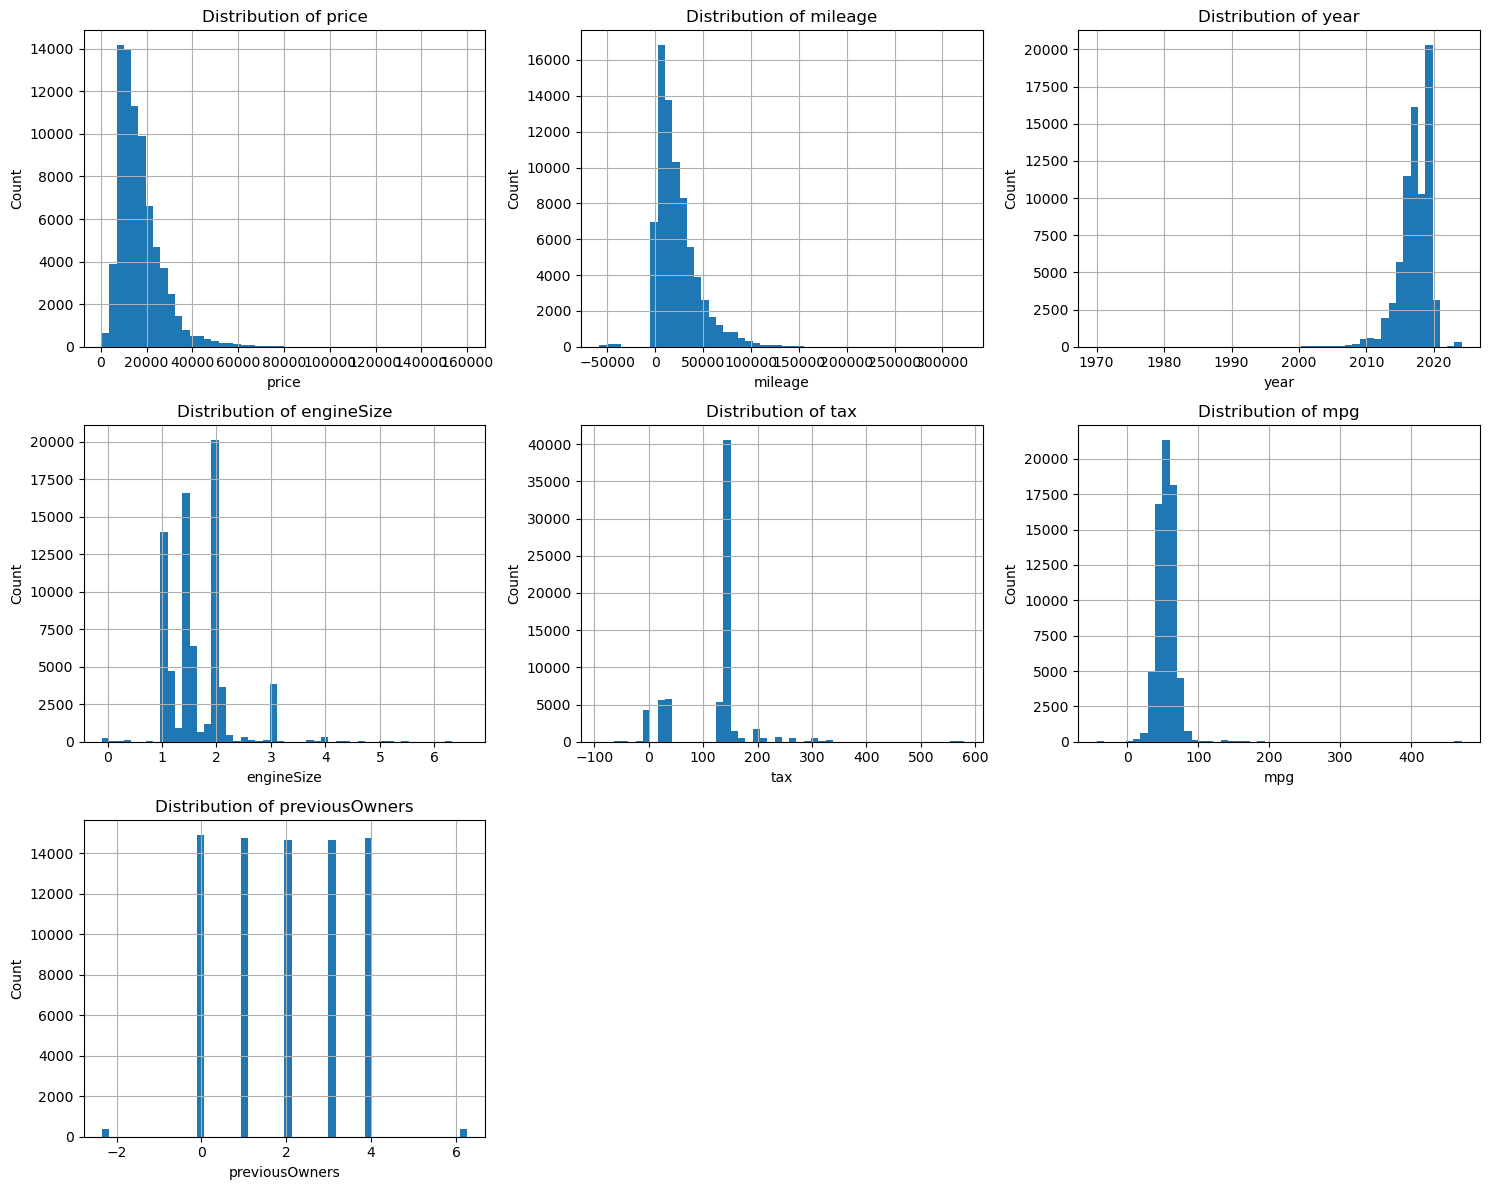

In [82]:
# Pick common numeric columns if present
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in train_copy.columns]

# Determine grid size (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to iterate easily
#Iterate over each one of the numeric collums and display a histogram where the Y is the count
# And the X is the respective value of each numeric collum
for i, col in enumerate(num_candidates):
    ax = axes[i]
    train_copy[col].dropna().hist(bins=50, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


From the previous histograms, we can conclude that the dataset contains the following issues:

* There are `year` values recorded after 2020, even though, the valid upper limit is 2020 so these entries can be set to NaN in order to be imputed later
* `engineSize` with a value of 0 which are obviously not realistic. These should be also set to NaN in order to be imputed later with adequate values.
* There are some negative values found in the following columns:
  * `previousOwners`
  * `tax`
  * `mpg`
  * `mileage`
* The negative values could be either multiplied by (-1) when appropriate or set to NaN in order to be imputed later. In some cases it might even make sense to remove the rows entirely. This will be further analyzed in this same pipeline phase
* Several numerical features show strong right-skewness, particularly `mileage`, `mpg`, and also `tax`, which affects linear models since it violates the Gauss-Markov assumptions.
* `price` is also right-skewed, so a log transformation of the target value (price) might be considered in order to improve the model's generalization performance by not overfitting to lower end cars.

<a class="anchor" id="3_1_6">

### **3.1.6** Potential Outliers
[Back to TOC](#toc)
</a>

Based on the conclusions drawn from the feature distributions, more specifically the presence of both unrealistic values (e.g., negative values, years beyond 2020, engine sizes of 0) and extreme outliers on the higher end, it is evident that the dataset contains several potential outliers that need to be addressed during the data preprocessing phase.

However, in order to be sure that we were aware of all potential outliers, we decided to create box plots for each numerical feature to visually identify outliers and extreme values.

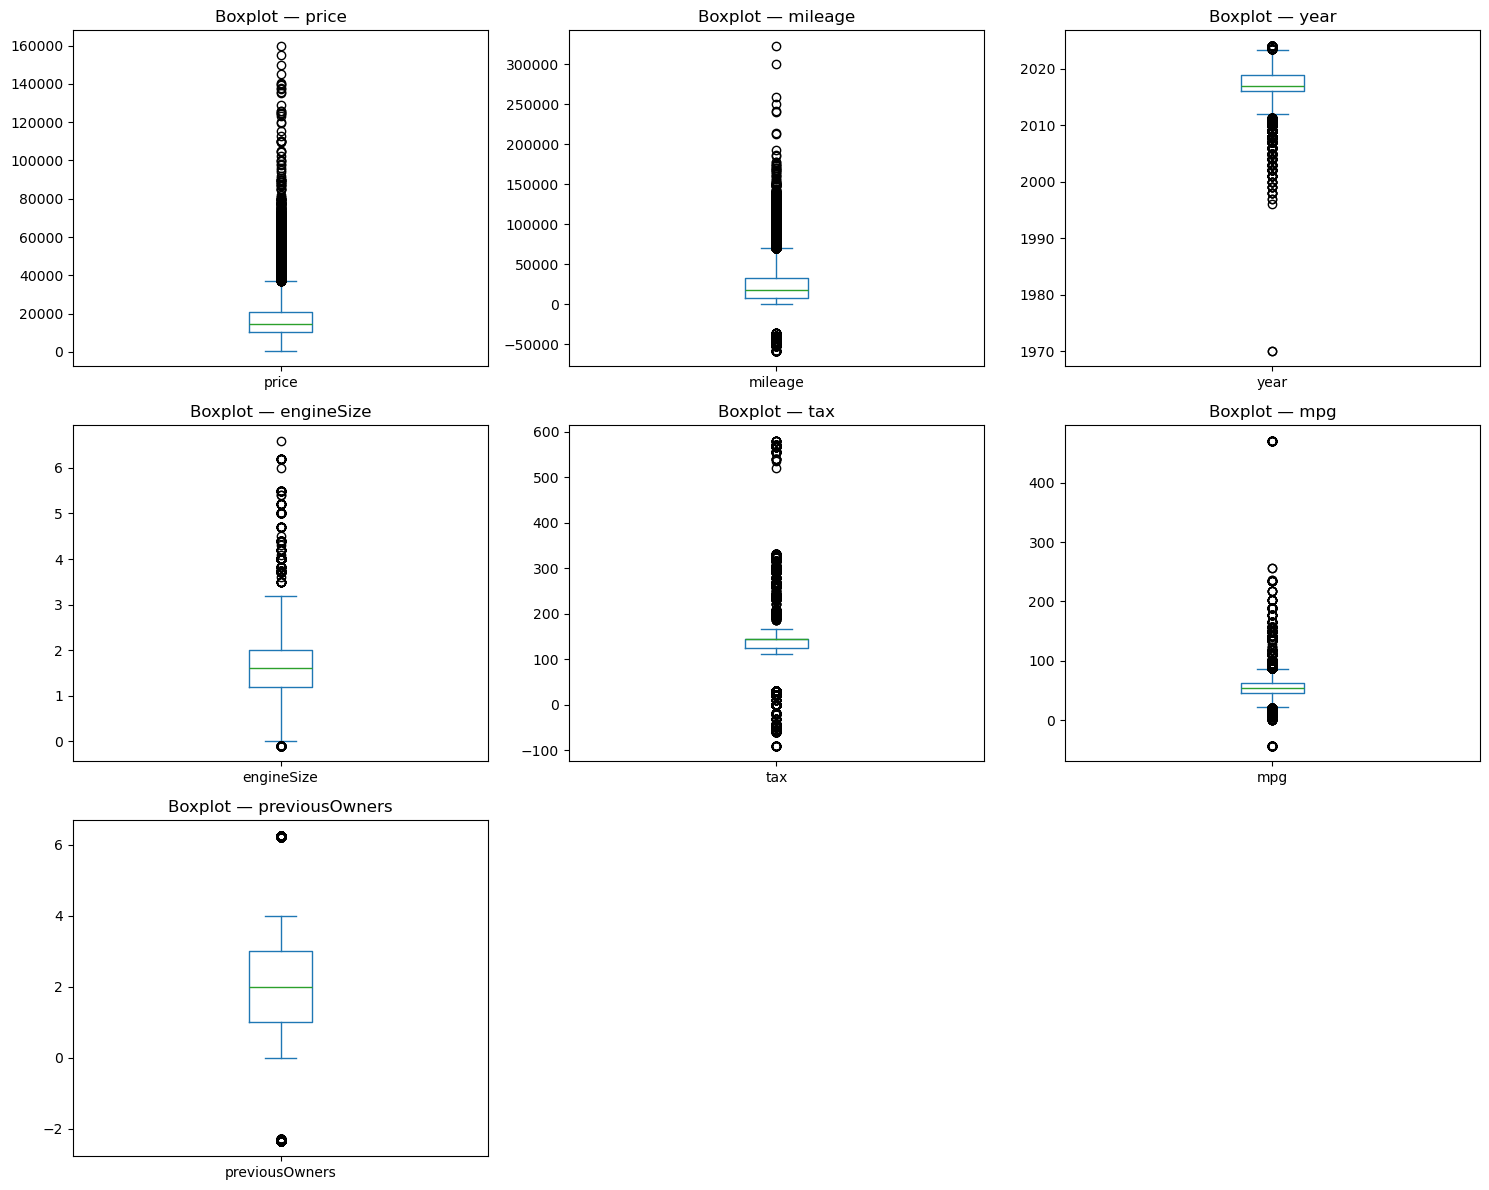

In [83]:

# Select numeric columns available
num_candidates = [c for c in ['price', 'mileage', 'year', 'engineSize', 'tax', 'mpg', 'previousOwners'] if c in train_copy.columns]

# Set grid layout (3 columns per row)
n_cols = 3
n_rows = (len(num_candidates) + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_candidates):
    ax = axes[i]
    train_copy[[col]].dropna().plot(kind="box", ax=ax, title=f"Boxplot — {col}")
    ax.set_xlabel("")  # cleaner look

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Besides all of the previous issues, the box plots revealed additional extreme outliers in features such as `year`, and `mpg`, where we have some cars with extremely high `mpg` values that are not realistic(e.g., above 400), and some other cars with very low `year` values (e.g., 1970s) which are also not realistic and could end up acting as noise. All of these outliers will be handled in the data preparation phase.

<a class="anchor" id="3_1_7">

### **3.1.7** Categorical Overview
[Back to TOC](#toc)
</a>

This section is the equivalent of the previous ones, but for categorical features. Here we will analyze the distributions of categorical features and check for any invalid or inconsistent values.

In [84]:
# Identify all categorical columns (dtype 'object') in the DataFrame
cat_cols = [c for c in train_copy.columns if train_copy[c].dtype == 'object']

# Initialize a list to store summary DataFrames for each categorical column
summary = []

# Loop over each categorical column
for c in cat_cols:
    # Get value counts for the column, including NaN (NO LIMIT)
    vc = train_copy[c].value_counts(dropna=False)
    
    # Create a DataFrame with the category names and counts, add the column name
    summary.append(
        pd.DataFrame({
            "category": vc.index.astype(str),  # Ensure categories are strings
            "count": vc.values
        }).assign(column=c)
    )

# If there are any categorical columns, concatenate their summaries and display
if summary:
    summary_df = pd.concat(summary, ignore_index=True)
    display(summary_df)
else:
    print("No categorical columns detected.")

,category,count,column
0,Ford,14808,Brand
1,Mercedes,10754,Brand
2,VW,9780,Brand
3,Opel,8645,Brand
4,BMW,6968,Brand
...,...,...,...
880,other,2,fuelType
881,HYBRI,2,fuelType
882,ybri,1,fuelType
883,ETRO,1,fuelType


* By observing the top categories for each categorical column, we can identify likely invalid or misspelled entries.

* For example, in `Brand` we see `ord` instead of `Ford` and `ercedes` instead of `Mercedes`.

* Similar issues exist in `Transmission` or `FuelType`, indicating a need for data cleaning.

* Similar issues may also exist in `Model` but are not observable from the top categories alone.

<a class="anchor" id="3_1_8">

### **3.1.8** Correlation Analysis (Numerical Features)
[Back to TOC](#toc)
</a>

Now we will analyze the correlations between numerical features using a heatmap to visualize the correlation matrix. This might help us identify any strong linear relationships between features but also redundant features that could be removed later.

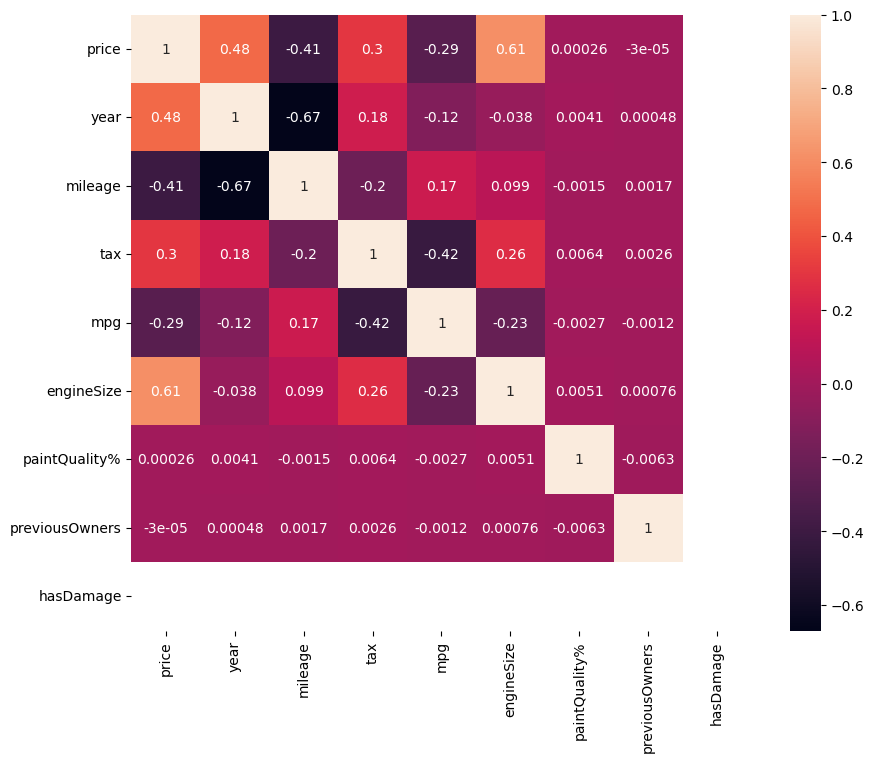

In [85]:
# Generate and display a correlation heatmap for numeric columns in the DataFrame
fig = plt.figure(figsize=(10, 8))

# Identify all numeric columns, excluding 'carID'

num_cols = train_copy.select_dtypes(include=['number']).columns.drop('carID').tolist()

# Proceed only if there are at least two numeric columns

if len(num_cols) > 1:
# Compute the correlation matrix for numeric columns
    corr = train_copy[num_cols].corr(numeric_only=True)

if 'price' in corr.columns:
    # Reorder columns/rows so price appears first in the correlation matrix
    cols = ['price'] + [col for col in corr.columns if col != 'price']
    corr = corr.loc[cols, cols]

    # heatmap of the correlation matrix
    ax = sns.heatmap(data=corr, annot=True)
else:
    print("Not enough numeric columns for correlation matrix.")


# display the heatmap
plt.show()


We can observe the following significant correlations:

- **Strong positive correlation** between `engineSize` and `price` (**61%**).  
- **Strong negative correlation** between `year` and `mileage` (**–67%**).  
- **Moderate positive correlation** between `price` and `year` (**48%**).  
- **Moderate negative correlations** between:  
  - `price` and `mileage` (**–41%**)  
  - `tax` and `mpg` (**–42%**)

Most of these correlations seem predictable and logical and will serve as valuable insights for both future data imputation strategies and feature engineering.

<a class="anchor" id="3_1_9">

### **3.1.9** Bivariate Relationships w.r.t. Target (price)
[Back to TOC](#toc)
</a>

In this section, we will explore the bivariate relationships between each numeric feature and the target variable, `price`. This analysis will help us understand how each feature influences the target and identify any potential patterns or trends that could be useful for our predictive models.

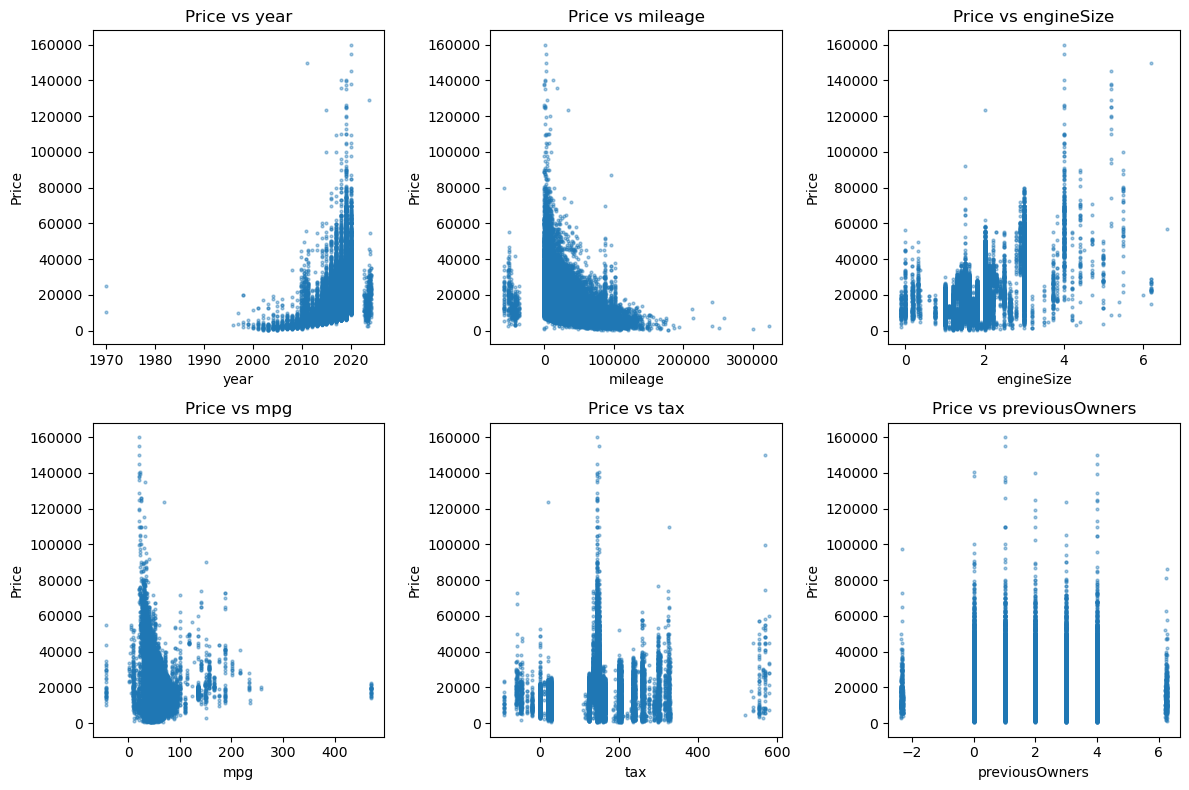

In [86]:
# Select numeric predictor columns that exist in the DataFrame
num_candidates = [c for c in ['year', 'mileage', 'engineSize', 'mpg', 'tax', 'previousOwners'] if c in train_copy.columns]

# Define grid layout for subplots (3 columns per row)

n_cols = 3

# ceiling division to fit all plots
n_rows = (len(num_candidates) + n_cols - 1) // n_cols

# Create figure and axes for subplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # Flatten axes array for easy iteration

# Loop through each numeric column and plot Price vs that column

for i, col in enumerate(num_candidates):
    ax = axes[i]
    # Create a scatter plot for the numeric variable against price
    ax.scatter(train_copy[col], train_copy['price'], s=4, alpha=0.4)
    ax.set_title(f"Price vs {col}")  # Set subplot title
    ax.set_xlabel(col)               # Label x-axis with column name
    ax.set_ylabel("Price")           # Label y-axis with 'Price'

# Hide any unused subplot axes if there are fewer plots than grid slots

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout spacing and display all scatter plots

plt.tight_layout()
plt.show()


The scatter plots reveal several important relationships between the numeric features and the target variable, `price`:

* As expected, newer cars (closer to the year `2020`) tend to have higher prices. However, any values beyond the maximum valid `year` (2020) produce unrealistic price relationships, indicating data errors.

* The same goes for `mileage`, cars with lower mileage are generally more expensive, but the presence of negative `mileage` values is invalid, yet they still appear to have associated prices.

* We can also observe the fact that other features contain invalid values that were already identified previously and that will be addressed in the data preparation phase.

<a class="anchor" id="3_1_10">

### **3.1.10** Data Quality Checks
[Back to TOC](#toc)
</a>

In this section, we will perform some quality checks on the numeric features to identify and address any invalid or inconsistent values that could have gone unnoticed during the initial exploration phase.

In [87]:
# Identify cars with a 'year' later than 2020 — such records should not exist
print("Cars with year greater than 2020: " + str((train_copy['year'] > 2020).sum()))

# Check for cars with engine sizes outside the realistic range (0.8 to )
print("Cars with unusual engine size: " + str(((train_copy['engineSize'] > 6.2) | (train_copy['engineSize'] < 0.8)).sum()))

print("Years before 2000: ", train_copy.loc[train_copy['year'] < 2000, 'year'].unique())

# Check integer-type columns ('year', 'previousOwners') for non-integer values
int_cols = ['year', 'previousOwners']
for col in int_cols:
# Identify values that are not integers
    non_int_mask = (train_copy[col] % 1 != 0)
    count_non_int = non_int_mask.sum()
    print(f"Float numbers in {col}: {count_non_int} non-integer values")

Cars with year greater than 2020: 358
Cars with unusual engine size: 575
Years before 2000:  [1996. 1998. 1970. 1999. 1997.]
Float numbers in year: 2214 non-integer values
Float numbers in previousOwners: 2284 non-integer values


From these checks, we identified several data quality issues that need to be addressed besides those already mentioned before:

* Both `year` and `previousOwners` have float values in 2214 and 2284 records respectively, which is not logical since these features should only contain integer values. And so this issues will be evaluated in the next cells and then addressed in the data preparation phase.

* In regards to the `year` feature, we found that before 2000, there are only entries for 5 different years(1996, 1998, 1970, 1999, 1997) which are not representative of the dataset and could potentially introduce noise. Therefore, we will consider setting these values to NaN for imputation later on.

After the unusual float values in previousOwners and year, we also wanted to check if those errors also existed in other numerical columns:

In [88]:
print("Weird float in engineSize: ", train_copy.loc[(train_copy['engineSize']*10) % 1 != 0, 'engineSize'].value_counts().sum())
print(train_copy.loc[(train_copy['engineSize']*10) % 1 != 0, 'engineSize'].value_counts())

print("Weird float in tax: ", train_copy.loc[train_copy['tax'] % 1 != 0, 'tax'].value_counts().sum())
print(train_copy.loc[train_copy['tax'] % 1 != 0, 'tax'].value_counts())

print("Weird float in mileage: ", train_copy.loc[train_copy['mileage'] % 1 != 0, 'mileage'].value_counts().sum())
print(train_copy.loc[train_copy['mileage'] % 1 != 0, 'mileage'].value_counts())

print("Weird float in mpg: ", train_copy.loc[(train_copy['mpg']*10) % 1 != 0, 'mpg'].value_counts().sum())
print(train_copy.loc[(train_copy['mpg']*10) % 1 != 0, 'mpg'].value_counts())

Weird float in engineSize:  762
engineSize
-0.103493    84
 2.631200    80
 0.307074    65
 3.723712    63
 2.985793    52
 0.739534    52
 0.186425    52
 2.064119    51
 0.154529    39
 3.739235    38
 0.313407    35
 3.822758    27
 2.619641    25
 0.162866    24
 0.191462    21
 2.781776    19
 0.371127    18
 2.663113    17
Name: count, dtype: int64
Weird float in tax:  759
tax
 299.473504    77
-45.780610     76
 326.028233    62
 303.148891    59
-56.193202     56
 290.486785    55
-49.153541     54
-20.241079     53
-60.684095     40
 316.487189    35
 327.915778    34
-43.242082     33
-91.121630     25
-18.330743     23
 277.384254    23
 316.296306    21
-31.914945     18
 294.843409    15
Name: count, dtype: int64
Weird float in mileage:  755
mileage
 82584.134420     82
-42650.453719     78
 86705.854885     59
 85454.586292     55
-50755.210230     54
 83688.655392     49
-48190.655673     48
-42707.564215     43
-52618.457894     39
-58540.574478     39
 101153.348285   

Given the nature of those values they are most likely data errors as well, so we will set them to nan for later imputation.

<a class="anchor" id="3_1_11">

### **3.1.11** Negative Values Analysis
[Back to TOC](#toc)
</a>

In this section, we will specifically analyze the negative values present in certain numeric features to determine their validity and decide on appropriate handling strategies to be taken during data preparation.

<a class="anchor" id="3_1_11_1">

#### **3.1.11.1** Negative Tax Values
[Back to TOC](#toc)
</a>

Regarding negative `tax` values, we're gonna be comparing the median of negative and positive `tax` values to determine if negative entries are likely sign errors and see if we find a correlation between them.

In the following snippet we made a scatter plot of `mpg` and `tax` since it was the highest correlation we found previously involving `tax`. This was made with the intention of showing that negative tax values do not follow the same pattern as positive tax values.

tax_sign
negative    -45.78061
positive    145.00000
Name: tax, dtype: float64


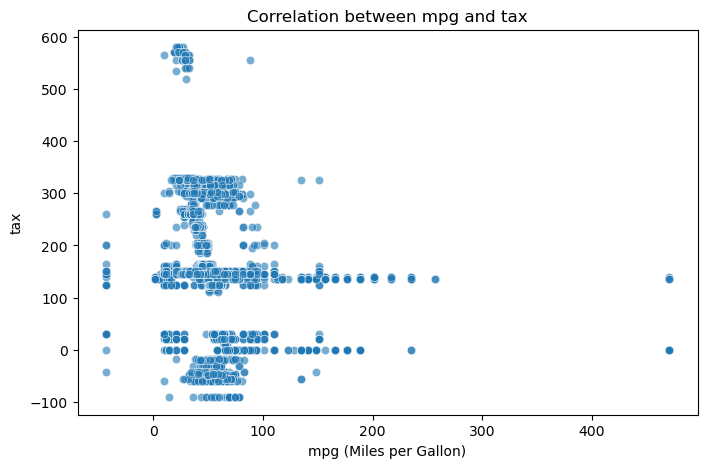

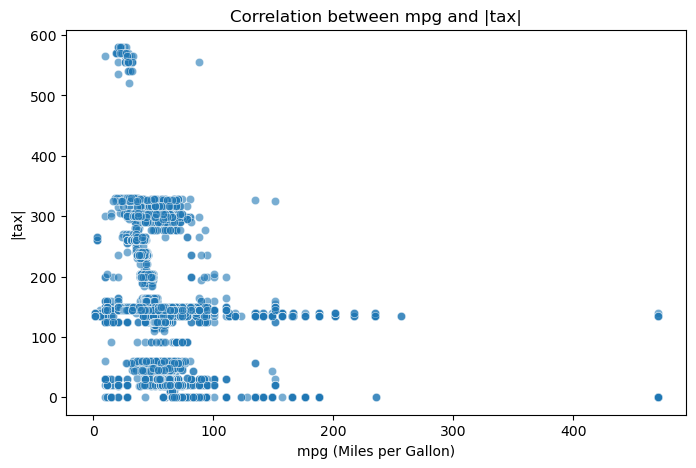

In [89]:
# classifying tax values as 'negative' or 'positive'
avg_tax_by_year = (
train_copy.assign(tax_sign=np.where(train_copy['tax'] < 0, 'negative', 'positive'))
.groupby(['tax_sign'])['tax']
.median()
)

# Print the median tax value for each sign group
print(avg_tax_by_year)

# Plot a scatter plot to visualize the relationship between mpg and tax
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train_copy, x='mpg', y='tax', alpha=0.6)
plt.title('Correlation between mpg and tax')
plt.xlabel('mpg (Miles per Gallon)')
plt.ylabel('tax')
plt.show()

# Plot a scatter plot to visualize the relationship between mpg and |tax|
df_abs = train_copy.copy()

num_cols = df_abs.select_dtypes(include="number").columns
df_abs[num_cols] = df_abs[num_cols].abs()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_abs, x="mpg", y="tax", alpha=0.6)
plt.title("Correlation between mpg and |tax|")
plt.xlabel("mpg (Miles per Gallon)")
plt.ylabel("|tax|")
plt.show()

* The median of negative tax values (ca.-46) is far from the median of positive values (ca.145). If negatives were simple sign errors, their absolute values would be similar to the positive distribution.
* A true sign error would produce mirror symmetry (e.g. +145 and −145), which is not observed here. (see first diagram)
* After applying `|tax|`, the negative values still do not align with the main positive-tax clusters, indicating they do not follow the same pattern. (see second diagram)

Given this we concluded that negative tax values likely represent invalid entries and should be treated as missing values (set to NaN) or removed rather than converted by changing their sign.

<a class="anchor" id="3_1_11_2">

#### **3.1.11.2** Negative Mileage Values
[Back to TOC](#toc)
</a>

Regarding negative `mileage` values, we're gonna be comparing the average mileage of cars with negative mileage values against those with positive mileage values to determine if the negative entries are likely sign errors or invalid data points.

In order to do that, we're gonna be grouping them by year as it can be seen in the following snippet:

In [90]:
# Create a new column that labels each mileage value as 'negative' or 'positive' based on its sign

avg_mileage_by_year = (
train_copy.assign(mileage_sign=np.where(train_copy['mileage'] < 0, 'negative', 'positive'))
# Group data by year and mileage sign, then calculate the mean mileage for each group
.groupby(['year', 'mileage_sign'])['mileage']
.mean()
# Reshape the result so each sign becomes a column
.unstack()
)

# Display the resulting table comparing mean negative and positive mileage per year
print(avg_mileage_by_year)

mileage_sign      negative      positive
year                                    
1970.000000            NaN  25678.500000
1996.000000            NaN  50000.000000
1997.000000            NaN  62500.000000
1998.000000            NaN  67147.750000
1999.000000            NaN  61446.200000
2000.000000            NaN  66589.200000
2001.000000            NaN  65864.466667
2002.000000  -52618.457894  83498.181818
2003.000000            NaN  89402.894139
2004.000000  -58540.574478  93506.562500
2005.000000            NaN  92521.210736
2006.000000            NaN  87987.370968
2007.000000  -50755.210230  85368.866088
2008.000000  -42707.564215  90949.845161
2009.000000  -42707.564215  82456.742820
2009.816757            NaN  31150.891892
2010.000000  -48568.891663  81670.193966
2010.268635            NaN  24029.684211
2010.371546            NaN  18839.714286
2010.565009            NaN  23144.383813
2010.676968  -42650.453719  20625.012658
2010.746403            NaN  19030.912281
2011.000000  -47

The following observations were made:

* The magnitudes do not mirror the positive values.
  If negative mileage were only a sign mistake, the absolute values of the negative group should be close to the positive mean for the same year (rough “mirror symmetry”).  
  Example:  
  * **2002**: mean negative ≈ **-52,618** vs mean positive ≈ **83,498** → `|negative|` is far smaller than the positive mean.  
  * **2004**: mean negative ≈ **-58,541** vs mean positive ≈ **93,507** → again, not a mirror.
* The negative group is unusually consistent across many years.

Conclusion: Negative mileage values likely represent invalid entries. A safe approach is to treat them as missing/invalid values (set to `NaN`) and then impute or remove, rather than multiplying by `-1`.

<a class="anchor" id="3_1_11_3">

#### **3.1.11.3** Negative previousOwners Values
[Back to TOC](#toc)
</a>

Regarding negative `previousOwners` values, we're gonna be comparing the average previousOwners of cars by `price` and by `year` respectively to determine if the negative entries are likely sign errors or invalid data points.

In [91]:
# Display frequency of all 'year' values, including missing entries
print(train_copy["previousOwners"].value_counts(dropna=False))
avg_year_by_po = (
    train_copy.groupby("previousOwners")["price"]
      .mean()
      .sort_index()
)

print(avg_year_by_po)
avg_year_by_po = (
    train_copy.groupby("previousOwners")["year"]
      .mean()
      .sort_index()
)

print(avg_year_by_po)

previousOwners
 0.000000    14879
 4.000000    14763
 1.000000    14754
 3.000000    14649
 2.000000    14644
 NaN          1550
-2.340306       84
 6.258231       78
 6.245835       64
-2.345650       58
-2.339360       58
 6.258371       50
 6.233082       46
-2.299439       43
 6.230180       37
-2.335123       37
-2.312260       34
 6.248251       32
-2.337445       25
 6.217724       21
 6.241779       20
-2.340102       17
 6.227898       15
-2.317331       15
Name: count, dtype: int64
previousOwners
-2.345650    17138.000000
-2.340306    12196.988095
-2.340102    14144.235294
-2.339360    25103.706897
-2.337445    15017.600000
-2.335123    22344.594595
-2.317331    16457.400000
-2.312260    22590.323529
-2.299439    10813.976744
 0.000000    16854.936824
 1.000000    16945.351227
 2.000000    16875.898525
 3.000000    16789.999590
 4.000000    16946.470501
 6.217724    13609.476190
 6.227898    10201.400000
 6.230180    24213.540541
 6.233082    10370.434783
 6.241779    14378.6

In this case its not as easy as in the other cases, but since the error is similar to the other errors we have seen so far, we should probably also set them to nan to be later imputed. We could also round the positive values.

<a class="anchor" id="3_1_12">

### **3.1.12** Non-Integer Year Values
[Back to TOC](#toc)
</a>

In this section, we will analyze the non-integer values present in the `year` feature to determine their validity and decide on appropriate handling strategies to be taken during data preparation.

We decided to check the non-integer year values and compare their average mileage against integer year values. This can be seen in the following snippet:

In [92]:
# Display frequency of all 'year' values, including missing entries
print(train_copy["year"].value_counts(dropna=False))

# Compute mean mileage for each distinct year value
mean_mileage = train_copy.groupby("year")['mileage'].mean().reset_index()

# Separate years into non-integer and integer groups based on remainder check
float_years = mean_mileage[mean_mileage['year'] % 1 != 0]
int_years = mean_mileage[mean_mileage['year'] % 1 == 0]

# Display non-integer years and their corresponding mean mileage
print(float_years)

# Display integer years and their corresponding mean mileage
print(int_years)

year
2019.000000    20271
2017.000000    16146
2016.000000    11502
2018.000000    10304
2015.000000     5733
2020.000000     3174
2014.000000     2930
2013.000000     1902
NaN             1491
2012.000000      478
2011.000000      318
2010.000000      241
2009.000000      228
2008.000000      158
2007.000000      123
2010.676968       82
2023.116964       77
2005.000000       64
2006.000000       62
2010.746403       58
2023.977311       55
2023.389822       53
2011.210853       50
2010.565009       47
2023.267989       43
2023.605276       39
2009.816757       37
2010.371546       35
2004.000000       35
2024.121759       34
2003.000000       29
2023.367078       26
2002.000000       25
2012.695740       21
2010.268635       20
2022.696685       19
2011.111188       15
2001.000000       15
2022.878006       12
2000.000000        6
1998.000000        5
1999.000000        5
1970.000000        2
1997.000000        2
1996.000000        1
Name: count, dtype: int64
           year       mi

* **Some non-integer years are clearly invalid given the dataset constraint (≤ 2020).**  
  Values such as `2022.x`, `2023.x`, and `2024.x` cannot be fixed by rounding, because they remain outside the allowed range and should be treated as invalid.
* **The mileage patterns suggest these entries do not behave like true years.**  
  For example, vehicles with `year = 2010.676968` have an average mileage of around **19,000 km**, while the years you could round it to are **~78,922 km (2010)** and **~69,547 km (2011)**. These non-integer values do not fit smoothly into this progression.

Conclusion: Instead of rounding, non-integer (and out-of-range) `year` values should be treated as invalid/missing and then imputed or removed.

<a class="anchor" id="3_1_12">

### **3.1.13** Key Takeaways for the Data Preparation Phase
[Back to TOC](#toc)
</a>

The exploratory analysis revealed several data quality issues that must be addressed before modeling. Categorical variables contain misspellings and inconsistent labels (e.g., in `Brand`, `transmission`, and `fuelType`), requiring standardization. Multiple numerical features include invalid values, such as years beyond 2020, zero engine sizes, and negative values in `mileage`, `mpg`, `tax`, and `previousOwners`, which should be treated as missing and handled through imputation or filtering. Numerical values also have unusual float values that likely represent errors.

Most numerical variables are right-skewed and contain many outliers, indicating that robust scaling is preferable if outliers are retained. The target variable `price` is also right-skewed and might benefit from a log transformation. Additionally, some features are unsuitable for modeling: `paintQuality%` should be removed, and `hasDamage` is nearly constant and provides limited information. Finally, several columns require data type corrections (e.g., `year` and `previousOwners` to integers) after cleaning.

<a class="anchor" id="4">

# **4. Data Preparation**
[Back to TOC](#toc)
</a>

Data preparation is an indispensable in the machine learning project, as it directly impacts the performance and reliability of the model. 
In this phase, the objective is to transform the raw data into a format that can be effectively utilised for training and evaluation purposes. This involves a series of steps, including data cleaning, handling missing values, feature engineering, and ensuring the proper distribution of data between the training and validation sets. Proper data preparation not only enhances the accuracy of the model but also ensures that the results are generalizable and unbiased. The goal was to create small functions for each step and then eventually integrate them into transformers into a final cohesive data preparation pipeline. 

<a class="anchor" id="4_1">

## **4.1** Data Partition

[Back to TOC](#toc)
</a>

Partitioning the dataset before preprocessing is a crucial step in building and evaluating a reliable model. Performing preprocessing on the entire dataset prior to splitting can unintentionally transfer information from the validation or test set into the training set, leading to data leakage and overly optimistic performance estimates. By partitioning first, we ensure that preprocessing steps are applied independently to the training and validation sets, preserving the model's generalizability and providing a more accurate assessment of its performance.

As part of this strategy, the independent variables were initially separated from the target, and the train_test_split() method from the scikit-learn library was then deployed to divide the data into training and validation sets. This approach guarantees that the model is trained on one portion of the data and evaluated on another, unseen portion, thus facilitating the assessment of its performance and generalisation ability. The validation of the model on separate data helps to identify potential overfitting and ensures that the model performs well on unseen data.

NOTE: Data partitioning is performed at this stage solely for illustrative purposes, allowing us to verify that all components work together seamlessly. A dedicated model evaluation function will be implemented later to handle partitioning and apply the appropriate preprocessing steps based on the selected method.

In [93]:
# Splitting the training dataset into independent variables (X) and target (Y)
X = train_copy.drop(columns=["price"])
y = train_copy["price"]
X_test = test.copy()
# Splitting the dataset into training and validation sets (for illustration purposes)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

<a class="anchor" id="4_1">

## **4.2** Type Casting
[Back to TOC](#toc)
</a>

Type casting should be done at the beginning of the data preparation phase to ensure that each feature is represented in the most appropriate format for analysis and modeling. Proper type casting helps to optimize memory usage, improve computational efficiency, and ensure that the data is interpreted correctly by machine learning algorithms.

In [94]:
X_train = conversion_dtypes(X_train)
X_val = conversion_dtypes(X_val)
X_test = conversion_dtypes(X_test)

<a class="anchor" id="4_2">

## **4.3** Mapping and Normalization Of Features Values
[Back to TOC](#toc)
</a>

As previously mentioned in topic 3.1, a number of issues were identified regarding invalid values in numerical featutes, and these are now going to be addressed. However, we also noticed that some categorical features contained inconsistent or invalid entries by looking at their bar charts labels. To ensure data quality, we will map these values to their correct categorical counterparts first.  


In [95]:
# Firstly we make all string columns to lowercase for consistency
for c in X_train.select_dtypes(include="string").columns:
    X_train[c] = X_train[c].str.lower()
for c in X_val.select_dtypes(include="string").columns:
    X_val[c] = X_val[c].str.lower()

In order to map these values to their correct forms, we created a mapping dictionary for each one of them in order to correct them.
The ones, we couldn't map, we will set them as NaN, so we can impute them later.

<a class="anchor" id="4_2_1">

### **4.3.1** Transmission Normalization and Mapping
[Back to TOC](#toc)
</a>

In [96]:
# Look into the unique transmission names
unique_transmissions = X_train["transmission"].dropna().unique().tolist()
print("\nUnique Transmission in 'transmission':\n", unique_transmissions)
print(f"\nNumber of unique transmissions: {len(unique_transmissions)}")


Unique Transmission in 'transmission':
 ['Manual', 'unknow', 'automatic', 'Semi-Auto', 'MANUAL', 'anual', 'SEMI-AUTO', 'emi-Auto', 'manual', 'Automatic', 'semi-auto', 'AUTOMATIC', 'Manua', 'Semi-Aut', 'unknown', 'Automati', 'utomatic', 'utomati', 'SEMI-AUT', 'ANUAL', 'anua', 'emi-Aut', 'AUTOMATI', 'nknown', 'UNKNOWN', 'manua', 'MANUA', 'Other', 'automati', 'emi-auto', 'EMI-AUTO', 'semi-aut', 'UTOMATIC']

Number of unique transmissions: 33


In [97]:
# X_train = apply_transmission_mapping(X_train)
# X_val = apply_transmission_mapping(X_val)

<a class="anchor" id="4_2_2">

### **4.3.2** Fuel Type Normalization and Mapping
[Back to TOC](#toc)
</a>

In [98]:
# Look into the unique fuel type names
unique_fuel_types = X_train["fuelType"].dropna().unique().tolist()
print("\nUnique Fuel type in 'fuelType':\n", unique_fuel_types)
print(f"\nNumber of unique fuel types: {len(unique_fuel_types)}")


Unique Fuel type in 'fuelType':
 ['Petrol', 'Hybrid', 'Diesel', 'etrol', 'Petro', 'diesel', 'PETROL', 'HYBRID', 'Other', 'iesel', 'etro', 'DIESEL', 'hybrid', 'petrol', 'Diese', 'Hybri', 'Othe', 'ybrid', 'diese', 'PETRO', 'petro', 'ETROL', 'Electric', 'DIESE', 'IESEL', 'OTHER', 'YBRID', 'ther', 'iese', 'other', 'ybri', 'HYBRI', 'ETRO']

Number of unique fuel types: 33


In [99]:
# X_train = apply_fuel_mapping(X_train)
# X_val = apply_fuel_mapping(X_val)

<a class="anchor" id="4_3_3">

### **4.3.3** Model Normalization and Mapping
[Back to TOC](#toc)
</a>

In [100]:
# Look into the unique model names
unique_models = X_train["model"].dropna().unique().tolist()
print("\nUnique Model in 'model':\n", unique_models)
print(f"\nNumber of unique models: {len(unique_models)}")


Unique Model in 'model':
 ['Fiesta', 'Mokka X', 'Yaris', 'Corsa', 'Q3', 'Focus', 'Q2', 'EcoSport', 'Polo', '4 Series', 'Up', 'Roomster', 'Meriva', 'Golf', 'C Class', 'E Class', 'A Class', 'Insignia', 'X1', 'A5', 'A3', 'A4', 'Zafira', 'B Class', 'Mokka', 'Kuga', 'Karoq', 'Astra', 'V Class', 'Ka+', '1 Series', 'A1', 'RAV4', 'Scirocco', 'T-Roc', 'Kodiaq', 'Edge', 'Mondeo', 'Aygo', 'A', 'Touran', '5 Series', 'insignia', '6 Series', '3 Series', 'Rapid', 'Tucson', 'Fiest', 'Prius', 'Grand C-MAX', '2 Series', 'Touareg', 'C-MAX', 'GLC Class', 'Superb', 'Q5', 'X5', 'I20', 'astra', 'Tiguan', 'Citigo', 'Yeti Outdoor', 'C-HR', 'I10', 'Arteon', 'T-Cross', 'Galaxy', 'Octavia', 'Fabia', 'CL Class', 'Passat', 'A6', 'S3', 'CLS Class', 'S Class', 'Santa Fe', 'Crossland X', 'Zafira Tourer', 'I800', 'Corolla', '3 SERIES', 'IX20', 'FIESTA', 'ASTRA', 'Kona', 'TT', 'GLE Class', '3 series', 'fiesta', 'Auris', 'corsa', 'Hilux', 'X3', '1 SERIES', 'c class', 'Tucso', 'Ioniq', 'I30', 't-cross', 'golf', 'Grandlan

In [101]:
# X_train = apply_model_mapping(X_train)
# X_val = apply_model_mapping(X_val)

<a class="anchor" id="4_2_4">

### **4.3.4** Brand Normalization and Mapping
[Back to TOC](#toc)
</a>

In [102]:
# Look into the unique brand names
unique_brands = X_train["Brand"].dropna().unique().tolist()
print("\nUnique Brand in 'brand':\n", unique_brands)
print(f"\nNumber of unique brands: {len(unique_brands)}")


Unique Brand in 'brand':
 ['Ford', 'Opel', 'Toyota', 'Audi', 'ord', 'ford', 'vw', 'BMW', 'VW', 'Skoda', 'Mercedes', 'W', 'BM', 'Hyundai', 'udi', 'HYUNDAI', 'For', 'Aud', 'ercedes', 'Ope', 'bmw', 'OPEL', 'MERCEDES', 'FORD', 'TOYOTA', 'Mercede', 'opel', 'AUDI', 'V', 'skoda', 'toyota', 'SKODA', 'mercedes', 'oyota', 'audi', 'pel', 'Toyot', 'hyundai', 'MW', 'Skod', 'toyot', 'Hyunda', 'hyunda', 'koda', 'KODA', 'ercede', 'yundai', 'HYUNDA', 'FOR', 'ud', 'or', 'yunda', 'UDI', 'for', 'v', 'mw', 'ERCEDES', 'PEL', 'ope', 'aud', 'OPE', 'SKOD', 'ORD', 'kod', 'pe', 'w', 'AUD', 'MERCEDE', 'OYOTA', 'skod', 'mercede']

Number of unique brands: 71


In [103]:
# X_train = apply_brand_mapping(X_train)
# X_val = apply_brand_mapping(X_val)

When we know a model name, we can also infer the brand name. We create a mapping dictionary for this as well.

In [104]:
# X_train = fill_brand_from_model(X_train)
# X_val = fill_brand_from_model(X_val)

In [105]:
X_train = mapping_and_normalization(X_train)
X_val = mapping_and_normalization(X_val)
X_test = mapping_and_normalization(X_test)
#print unique values after mapping for each column
for col in X_train.columns:
    print(f"\nUnique {col} after mapping:\n", X_train[col].unique().tolist())


Unique carID after mapping:
 [17712, 60272, 54409, 60966, 2891, 30282, 3234, 26766, 27590, 27823, 69094, 23573, 12752, 73073, 49206, 75313, 65348, 67207, 39604, 43464, 43490, 63801, 69698, 8966, 28516, 37563, 22883, 3912, 167, 4178, 24182, 61787, 45888, 16577, 20705, 62323, 31232, 20261, 47192, 62483, 40734, 20108, 41664, 66657, 65471, 17351, 9833, 6938, 20807, 52689, 67324, 66155, 50698, 21205, 49478, 70407, 38727, 65235, 20298, 7345, 20987, 29905, 54458, 12911, 2795, 73870, 16316, 28662, 28968, 16594, 4598, 38144, 17340, 11715, 49877, 16095, 65277, 10298, 19472, 30798, 8949, 25676, 45106, 49792, 34742, 59998, 29677, 8884, 62422, 75876, 35592, 7789, 53777, 52603, 20922, 59949, 2429, 21503, 10272, 71841, 52147, 26481, 36849, 36174, 22195, 49199, 27244, 6865, 6877, 71306, 1294, 32300, 14892, 13907, 4769, 51960, 4920, 33952, 49599, 64526, 29106, 8565, 26917, 70928, 63207, 73572, 19815, 39814, 26380, 74623, 9428, 12750, 50162, 2899, 25779, 26967, 53950, 34445, 36305, 62808, 46748, 53379,

<a class="anchor" id="4_4">

## **4.4** Handling Invalid Outliers
[Back to TOC](#toc)
</a>

Outliers can significantly impact the performance of machine learning models, leading to skewed results and reduced accuracy. Therefore, it is crucial to identify and handle outliers appropriately during the data preparation phase.

<a class="anchor" id="4_4_1">

### **4.4.1** Year after 2020 and Non-Integer Year Values
[Back to TOC](#toc)
</a>

According to our previous analysis, we identified several `year` values that were recorded after 2020, which is beyond the valid range for our dataset. Additionally, we found non-integer `year` values that did not align with neither `mileage` trends of the that same rounded year or the next one. To ensure data integrity we will set these invalid `year` entries to NaN, allowing us to handle them appropriately during the imputation phase.

In [106]:
# Show year values after 2020

print("Year values after 2020:")
print(X_train.loc[X_train['year'] > 2020, 'year'])

# Show non-integer year values
print("Non-integer year values:")
print(X_train.loc[X_train['year'] % 1 != 0, 'year']) 

Year values after 2020:
16131    2023.605276
35756    2022.878006
2166     2023.267989
74591    2023.977311
65467    2023.605276
            ...     
36187    2023.267989
25351    2023.605276
51991    2023.267989
40764    2023.389822
70467    2023.267989
Name: year, Length: 274, dtype: float64
Non-integer year values:
15137            NaN
19440            NaN
61105            NaN
41383            NaN
32126            NaN
            ...     
52083            NaN
70467    2023.267989
2695     2010.676968
35920            NaN
5311     2010.746403
Name: year, Length: 1757, dtype: float64


<a class="anchor" id="4_4_2">

### **4.4.2** Engine Size below 0.8L and above 6.2L
[Back to TOC](#toc)
</a>

We have seen in data exploration that there are some outliers in engine size below 0.8L and above 6.2L.
From our domain knowledge, we know that cars in our dataset should have engine sizes between 1.0L and 6.2L.
We will put these values to na, so we can impute them later.

In [107]:
# Count affected entries
low_engine_size_count = X_train[X_train['engineSize'] < 0.8].shape[0]
high_engine_size_count = X_train[X_train['engineSize'] > 6.2].shape[0]
print(f"Number of entries with engine size below 0.8L:  {low_engine_size_count}")
print(f"Number of entries with engine size above 6.2L:  {high_engine_size_count}")

Number of entries with engine size below 1.0L:  459
Number of entries with engine size above 6.2L:  1


<a class="anchor" id="4_4_3">

### **4.4.3** Other process errors found in data exploration
[Back to TOC](#toc)
</a>

During the data exploration phase, several other process errors were identified that could potentially compromise the integrity of the dataset. These errors include negative values in features where only positive values are valid, such as mileage, tax, mpg, engine size, and previous owners. To address these issues, we will set these values to NaN, allowing us to handle them appropriately during the imputation phase.

For that purpose, we created a dedicated transformer called `OutlierHandler` that sets these invalid values to NaN. It's also important to mention that it also drops the `paintQuality` feature as previously mentioned in [section 3.1.1](#3_1_1) since it is not useful for our model and so the earlier we drop it in our pipeline, the better.

In [108]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X = handle_invalid_outliers(X)
        return X

In [109]:
fitted_outlier_handler = OutlierHandler().fit(X_train) # symbolic fit
X_train = fitted_outlier_handler.transform(X_train)
X_val = fitted_outlier_handler.transform(X_val)
X_test = fitted_outlier_handler.transform(X_test)
print("After handling invalid outliers:")
for col in ["fuelType", "transmission", "Brand", "model"]:
    print(f"\nUnique {col} after mapping:\n", X_train[col].unique().tolist())
for col in ["fuelType", "transmission", "Brand", "model"]:
    print(f"\nUnique {col} after mapping:\n", X_val[col].unique().tolist())   
for col in ["fuelType", "transmission", "Brand", "model"]:
    print(f"\nUnique {col} after mapping:\n", test[col].unique().tolist())    

After handling invalid outliers:

Unique fuelType after mapping:
 ['Petrol', 'Hybrid', 'Diesel', 'Other', nan, 'Electric']

Unique transmission after mapping:
 ['Manual', nan, 'Automatic', 'Semi-Auto', 'Other']

Unique Brand after mapping:
 ['Ford', 'Opel', 'Toyota', 'Audi', 'Volkswagen', 'BMW', 'Škoda', 'Mercedes-Benz', nan, 'Hyundai']

Unique model after mapping:
 ['Fiesta', 'Mokka X', 'Yaris', 'Corsa', 'Q3', 'Focus', 'Q2', 'EcoSport', 'Polo', '4 Series', 'Up', 'Roomster', 'Meriva', 'Golf', 'C-Class', 'E-Class', 'A-Class', 'Insignia', 'X1', 'A5', 'A3', 'A4', 'Zafira', 'B-Class', 'Mokka', 'Kuga', 'Karoq', 'Astra', 'V-Class', 'Ka+', '1 Series', 'A1', 'RAV4', 'Scirocco', 'T-Roc', 'Kodiaq', 'Edge', 'Mondeo', 'Aygo', nan, 'Touran', '5 Series', '6 Series', '3 Series', 'Rapid', 'Tucson', 'Prius', 'Grand C-MAX', '2 Series', 'Touareg', 'C-MAX', 'GLC-Class', 'Superb', 'Q5', 'X5', 'i20', 'Tiguan', 'Citigo', 'Yeti Outdoor', 'CH-R', 'i10', 'Arteon', 'T-Cross', 'Galaxy', 'Octavia', 'Fabia', 'CL-Cl

<a class="anchor" id="4_5">

## **4.5** Data Imputation  
[Back to TOC](#toc)
</a>

Data imputation is a critical step in the data preparation process, as it addresses the issue of missing values within the dataset. If left unaddressed, these sort of values can lead to biased analyses and reduced model performance.

<a class="anchor" id="4_5_1">

### **4.5.1** Imputation of Categorical Features  
[Back to TOC](#toc)
</a>

In order to impute the missing values of some of the categorical features we're gonna be using RandomForestClassifier. However, RandomForestClassifer only works with numerical values, so for that matter the other categorical features (whose values are gonna be used by the RFClassifier) need to be encoded into numerical values.

- Firstly, we adopted a cardinality-aware encoding strategy for categorical features where low-cardinality features (Brand, Transmission, FuelType) were encoded using One-Hot Encoding, while the high-cardinality variable (Model) was encoded using Ordinal Encoding to prevent excessive feature expansion [(section 4.5.3.1)](#4_5_3_1) .

- Secondly, we defined two transformer specifications (one for each encoding method), each encapsulated within its own Pipeline. These transformers were then combined using a `ColumnTransformer`, which was integrated into a final `Pipeline` template together with the selected `RandomForestClassifier`. This complete pipeline was subsequently used within each categorical feature imputation transformer [(section 4.5.3)](#4_5_3_2) .

 
- Finally, each one of these categorical imputation transformers is then part of a more broad imputation Pipeline that will also have the numerical features imputer transformers [(section 4.5.3.2)](#4_5_3_2) .

In regards to the internal logic of each of these categorical imputers, it is first checked whether the car model appears frequently enough in the dataset (we defined it as 10 appearances). If it does, we fill the missing value with that model’s most frequent category. If not, we encode the remaining categorical features using their respective pipelines and use an instance of RandomForestClassifier trained on complete rows to predict and impute the missing values. We took this approach because when mapping and normalizing the categorical features we noticed that there were still some unknown values that we couldn't map, so this way we can also impute those values.

<a class="anchor" id="4_5_1_1">

#### **4.5.1.1** Transmission Imputation (TransmissionImputer Class)
[Back to TOC](#toc)
</a>

Here the remaining cases that are not imputed with the most frequent transmission value per model are imputed using a RandomForestClassifier instance where the features ["Brand", "model", "fuelType", "engineSize", "year", "mpg" and "tax"] are used to train and then predict the missing values of the "transmission" feature.

In [110]:
class TransmissionImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=10):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        # store lookup tables learned from training data
        counts = df.dropna(subset=['transmission'])['model'].value_counts()
        self.valid_models_ = counts[counts >= self.min_model_count].index

        self.model_modes_ = (
            df.dropna(subset=['model', 'transmission'])
              .groupby('model')['transmission']
              .agg(lambda s: s.mode().iloc[0])
        )

        # Train ML model for remaining missing values
        train_df = df[df['transmission'].notna()].copy()

        features = [
            "transmission","Brand", "model", "fuelType",
            "engineSize", "year", "mpg", "tax",
        ]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['transmission'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for model in self.valid_models_:
            mask = (df['model'] == model) & (df['transmission'].isna())
            if model in self.model_modes_:
                df.loc[mask, 'transmission'] = self.model_modes_[model]

        # ML fallback
        missing_mask = df['transmission'].isna()
        if missing_mask.any():
            df.loc[missing_mask, 'transmission'] = self.ml_model_.predict(
                df.loc[missing_mask, self.features_]
            )           
        return df

<a class="anchor" id="4_5_1_2">

#### **4.5.1.2** FuelType Imputation (FuelTypeImputer Class)
[Back to TOC](#toc)
</a>

Here the remaining cases that are not imputed with the most frequent fuel type value per model are imputed using a RandomForestClassifier instance where the feature ["Brand", "model", "transmission", "engineSize", "year" and "mpg"] are used to train and then predict the missing values of the "fuelType" feature.

In [111]:
class FuelTypeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=10):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        counts = df.dropna(subset=['fuelType'])['model'].value_counts()
        self.valid_models_ = counts[counts >= self.min_model_count].index

        self.model_modes_ = (
            df.dropna(subset=['model', 'fuelType'])
              .groupby('model')['fuelType']
              .agg(lambda s: s.mode().iloc[0])
        )

        features = ['fuelType','Brand', 'model', 'transmission',
                    'engineSize', 'year', 'mpg']
        train_df = df[df['fuelType'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['fuelType'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for model in self.valid_models_:
            mask = (df['model'] == model) & (df['fuelType'].isna())
            df.loc[mask, 'fuelType'] = self.model_modes_.get(model, np.nan)

        # ML fallback
        missing = df['fuelType'].isna()
        if missing.any():
            df.loc[missing, 'fuelType'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

<a class="anchor" id="4_5_1_3">

#### **4.5.1.3** Brand Imputation (BrandImputer Class)
[Back to TOC](#toc)
</a>

Here the remaining cases that are not imputed with the most frequent brand value per model are imputed using a RandomForestClassifier instance where the feature ["transmission", "engineSize", "fuelType", "mpg" and "model"] are used to train and then predict the missing values of the "brand" feature.

In [112]:
class BrandImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_model_count=20):
        self.pipeline_template = pipeline_template
        self.min_model_count = min_model_count

    def fit(self, X, y=None):
        df = X.copy()

        # rule-based brand per model
        self.model_to_brand_ = (
            df.dropna(subset=['Brand', 'model'])
              .groupby('model')['Brand']
              .agg(lambda s: s.mode().iloc[0])
        )

        # ML fallback
        features = ["Brand",'transmission', 'engineSize',
                    'fuelType', 'mpg', 'model']
        train_df = df[df['Brand'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['Brand'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        mask = df['Brand'].isna() & df['model'].notna()
        df.loc[mask, 'Brand'] = df.loc[mask, 'model'].map(self.model_to_brand_)

        # ML fallback
        missing = df['Brand'].isna()
        if missing.any():
            df.loc[missing, 'Brand'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

<a class="anchor" id="4_5_1_4">

#### **4.5.1.4** Model Imputation (ModelImputer Class)
[Back to TOC](#toc)
</a>

Here the remaining cases that are not imputed with the most frequent model value per model are imputed using a RandomForestClassifier instance where the feature ["Brand", "year", "engineSize", "mpg", "tax", "mileage", "fuelType" and "transmission"] are used to train and then predict the missing values of the "model" feature.

In [113]:
class ModelImputer(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline_template, min_brand_count=20):
        self.pipeline_template = pipeline_template
        self.min_brand_count = min_brand_count

    def fit(self, X, y=None):
        df = X.copy()

        # rule-based: most frequent model per (Brand, transmission)
        self.lookup_ = (
            df.dropna(subset=['Brand', 'transmission', 'model'])
              .groupby(['Brand', 'transmission'])['model']
              .agg(lambda s: s.value_counts().idxmax())
        )

        # ML fallback
        features = ['model','Brand', 'year', 'engineSize', 'mpg',
                    'tax', 'mileage', 'fuelType', 'transmission']
        train_df = df[df['model'].notna()]

        pipe = clone(self.pipeline_template)
        pipe.fit(train_df[features], train_df['model'])

        self.ml_model_ = pipe
        self.features_ = features
        return self

    def transform(self, X):
        df = X.copy()

        # rule-based fill
        for idx, row in df[df['model'].isna()].iterrows():
            key = (row['Brand'], row['transmission'])
            if key in self.lookup_.index:
                df.at[idx, 'model'] = self.lookup_.loc[key]

        # ML fallback
        missing = df['model'].isna()
        if missing.any():
            df.loc[missing, 'model'] = self.ml_model_.predict(
                df.loc[missing, self.features_]
            )
        return df

<a class="anchor" id="4_5_2">

### **4.5.2** Imputation of Numerical Features  
[Back to TOC](#toc)
</a>

For imputing missing numerical values, we primarily use the median of each feature. This approach preserves the central tendency of the data without being distorted by extreme values. In some cases, however, we also consider additional features like imputing year by segmenting the data into bins based on `mileage`, or imputing `tax` by segmenting the data into bins based on miles per gallon (`mpg`) as it can be seen in the following sections.

<a class="anchor" id="4_5_2_1">

#### **4.5.2.1** Mileage Imputation (MileageImputer Class)
[Back to TOC](#toc)
</a>

For `mileage` imputation, we use the yearly median mileage value of the training set to fill in missing values according to the `year` of the vehicle whose `mileage` is missing. We chose this approach because `mileage` is strongly correlated with the age of the vehicle as it can be seen in [section 3.1.8](#3_1_8) correlation matrix, and using the median helps to mitigate the influence of outliers.

In [114]:
class MileageImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.year_medians_ = df.groupby('year')['mileage'].median()
        self.global_median_ = df['mileage'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mileage'] = df['mileage'].fillna(
            df['year'].map(self.year_medians_)
        )
        df['mileage'] = df['mileage'].fillna(self.global_median_)
        return df

<a class="anchor" id="4_5_2_2">

#### **4.5.2.2** Year Imputation (YearImputer Class)
[Back to TOC](#toc)
</a>

For `year` imputation, we segment the data into bins based on `mileage` ranges and use the median `year` within each bin to fill in missing values. This way, we once again account for the relationship between `mileage` and `year`, as vehicles with higher mileage are typically older.

In [115]:
class YearImputer(BaseEstimator, TransformerMixin):
    def __init__(self, bins=30):
        self.bins = bins

    def fit(self, X, y=None):
        df = X.copy()

        df['mileage_bin'] = pd.cut(df['mileage'], bins=self.bins)
        self.bin_medians_ = df.groupby('mileage_bin')['year'].median()
        self.global_median_ = df['year'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mileage_bin'] = pd.cut(df['mileage'], bins=self.bins)

        df['year'] = df['year'].fillna(
            df['mileage_bin'].map(self.bin_medians_)
        )
        df['year'] = df['year'].fillna(self.global_median_)
        df.drop(columns='mileage_bin', inplace=True)
        return df

<a class="anchor" id="4_5_2_3">

#### **4.5.2.3** MPG Imputation (MPGImputer Class)
[Back to TOC](#toc)
</a>

For `mpg` imputation, we employ a hierarchical, median-based strategy derived from the training data. Missing values are first imputed using the median `mpg` for the corresponding combination of `model` and `fuelType`. However, if this information is unavailable, the imputation falls back to the median `mpg` for the associated `Brand` and `fuelType`. Remaining missing values are then filled using the median `mpg` for each `fuelType`, and finally, any unresolved cases are imputed with the global median `mpg` of the training set.

In [116]:
class MPGImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.model_medians_ = df.groupby(['model', 'fuelType'])['mpg'].median()
        self.brand_medians_ = df.groupby(['Brand', 'fuelType'])['mpg'].median()
        self.fuel_medians_ = df.groupby(['fuelType'])['mpg'].median()
        self.global_median_ = df['mpg'].median()
        return self

    def transform(self, X):
        df = X.copy()

        for idx, row in df[df['mpg'].isna()].iterrows():
            km = (row['model'], row['fuelType'])
            kb = (row['Brand'], row['fuelType'])
            if km in self.model_medians_.index:
                df.at[idx, 'mpg'] = self.model_medians_.loc[km]
            elif kb in self.brand_medians_.index:
                df.at[idx, 'mpg'] = self.brand_medians_.loc[kb]

        df['mpg'] = df['mpg'].fillna(df['fuelType'].map(self.fuel_medians_))
        df['mpg'] = df['mpg'].fillna(self.global_median_)
        return df

<a class="anchor" id="4_5_2_4">

#### **4.5.2.4** PreviousOwners Imputation (PreviousOwnersImputer Class)
[Back to TOC](#toc)
</a>

For `previousOwners` imputation, we simply use the median number of previous owners to fill in missing values, as there was no strong correlation found with other features that would justify a more complex imputation strategy.

In [117]:
class PreviousOwnersImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_ = X['previousOwners'].median()
        return self

    def transform(self, X):
        df = X.copy()
        df['previousOwners'] = df['previousOwners'].fillna(self.median_)
        return df

<a class="anchor" id="4_5_2_5">

#### **4.5.2.5** Tax Imputation (TaxImputer Class)
[Back to TOC](#toc)
</a>

For `tax` imputation, we also adopt a hierarchical, median-based strategy that incorporates both `mpg` and categorical attributes. The data is first discretized into bins based on `mpg` values, allowing the imputation process to account for differences in `mpg`. Missing `tax` values are initially imputed using the median `tax` for the corresponding combination of `model`, `fuelType`, and `mpg` bin. If this level of detail is unavailable, the method falls back to the median computed for `Brand`, `fuelType`, and `mpg` bin, followed by the median for `fuelType` and `mpg` bin. Any remaining missing values are then filled using the median `tax` for each `fuelType`, and finally the global median `tax` from the training set.

In [118]:
class TaxImputer(BaseEstimator, TransformerMixin):
    def __init__(self, bins=15):
        self.bins = bins

    def fit(self, X, y=None):
        df = X.copy()

        df['mpg_bin'] = pd.cut(df['mpg'], bins=self.bins)

        self.medians_one_ = df.groupby(['model', 'fuelType', 'mpg_bin'])['tax'].median()
        self.medians_two_ = df.groupby(['Brand', 'fuelType', 'mpg_bin'])['tax'].median()
        self.medians_three_ = df.groupby(['fuelType', 'mpg_bin'])['tax'].median()
        self.fuel_medians_ = df.groupby('fuelType')['tax'].median()
        self.global_median_ = df['tax'].median()
        return self

    def transform(self, X):
        df = X.copy()

        df['mpg_bin'] = pd.cut(df['mpg'], bins=self.bins)

        for idx, row in df[df['tax'].isna()].iterrows():
            km = (row['model'], row['fuelType'], row['mpg_bin'])
            kb = (row['Brand'], row['fuelType'], row['mpg_bin'])
            ke = (row['fuelType'], row['mpg_bin'])

            if km in self.medians_one_.index:
                df.at[idx, 'tax'] = self.medians_one_.loc[km]
            elif kb in self.medians_two_.index:
                df.at[idx, 'tax'] = self.medians_two_.loc[kb]
            elif ke in self.medians_three_.index:
                df.at[idx, 'tax'] = self.medians_three_.loc[ke]

        df['tax'] = df['tax'].fillna(df['fuelType'].map(self.fuel_medians_))
        df['tax'] = df['tax'].fillna(self.global_median_)
        return df

<a class="anchor" id="4_5_2_6">

#### **4.5.2.6** EngineSize Imputation (EngineSizeImputer Class)
[Back to TOC](#toc)
</a>

For `engineSize` imputation, we are once again adopting a hierarchical, median-based approach that is based on categorical vehicle attributes. Missing values are first imputed using the median `engineSize` for the corresponding combination of `model` and `fuelType`. If this information is unavailable, the method falls back to the median `engineSize` computed for the associated `Brand` and `fuelType`. Any remaining missing values are then filled using the median `engineSize` for each `model`, and finally, unresolved cases are imputed using the global median `engineSize` from the training set.

In [119]:
class EngineSizeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X.copy()

        self.model_medians_ = df.groupby(['model', 'fuelType'])['engineSize'].median()
        self.brand_medians_ = df.groupby(['Brand', 'fuelType'])['engineSize'].median()
        self.fuel_medians_ = df.groupby(['model'])['engineSize'].median()
        self.global_median_ = df['engineSize'].median()
        return self

    def transform(self, X):
        df = X.copy()

        for idx, row in df[df['engineSize'].isna()].iterrows():
            km = (row['model'], row['fuelType'])
            kb = (row['Brand'], row['fuelType'])
            if km in self.model_medians_.index:
                df.at[idx, 'engineSize'] = self.model_medians_.loc[km]
            elif kb in self.brand_medians_.index:
                df.at[idx, 'engineSize'] = self.brand_medians_.loc[kb]

        df['engineSize'] = df['engineSize'].fillna(df['model'].map(self.fuel_medians_))
        df['engineSize'] = df['engineSize'].fillna(self.global_median_)
        return df 

<a class="anchor" id="4_5_3">

### **4.5.3** Pipeline Definition
[Back to TOC](#toc)
</a>

In this section, we define the different pipelines used for data imputation

<a class="anchor" id="4_5_3_1">

#### **4.5.3.1** Encoding Pipelines
[Back to TOC](#toc)
</a>

The encoding pipelines are defined here. We can see both `low_card_pipeline` and `high_card_clas_pipeline` which are used for encoding low-cardinality and high-cardinality categorical features respectively on the data imputation transformers.

Whereas `high_card_reg_pipeline` is used for encoding high-cardinality categorical features later in this data preparation phase during the modelling transformers.
The main difference between both pipelines is that the `high_card_reg_pipeline` uses Target Encoding instead of Ordinal Encoding, as it has shown to perform better in regression tasks.

In [120]:
# Used for low-cardinality categorical features
low_card_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # or OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
])

# Used for high-cardinality categorical features like model in classification (imputation of categorical variables)
high_card_clas_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])

# Used for high-cardinality categorical features like model and mpg_bin (encoding of non-numeric variables further down the pipeline)
high_card_reg_pipeline = Pipeline([('target', TargetEncoder(
        target_type="continuous",              
        random_state=42
    ))])

<a class="anchor" id="4_5_3_2">

### **4.5.3.2** Data Imputation Pipeline 
[Back to TOC](#toc)
</a>

The data imputation pipeline is defined here. We can see that it contains all the categorical and numerical imputer transformers defined previously.

In [121]:
features_to_encode = ["Brand", "model", "transmission", "fuelType"]
pipeline_template = make_template_for(features_to_encode, imputation=True)

rule_imputer = Pipeline([
        ("transmission_imp", TransmissionImputer(pipeline_template)),
        ("fuelType_imp", FuelTypeImputer(pipeline_template)),
        ("brand_imp", BrandImputer(pipeline_template)),
        ("model_imp", ModelImputer(pipeline_template)),
        ("mileage_imp", MileageImputer()),
        ("year_imp", YearImputer()),
        ("mpg_imp", MPGImputer()),
        ("previousOwners_imp", PreviousOwnersImputer()),
        ("tax_imp", TaxImputer()),
        ("engineSize_imp", EngineSizeImputer()),
    ])

Here is the encoding pipeline that will be used later on right before the modelling phase.

In [122]:
# Pipeline for encoding categorical variables after imputation
rule_encoder = make_template_for(X_train.columns.tolist(), imputation=False, encoding=True)

Here is the SimpleImputer that is used to just set the `hasDamage` missing values to 1, as it was constant before.

In [123]:
class SimpleImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        print("Fitting SimpleImputer...")
        return self

    def transform(self, X):
        X = X.copy()
        print("Performing simple imputation...")
        # Only very simple imputation
        if "hasDamage" in X.columns:
            X["hasDamage"] = X["hasDamage"].fillna(1)
        print("Simple imputation completed. Starting rule-based + ML imputation...")
        return X

In [124]:
fitted_simple_Imputer = SimpleImputer().fit(X_train, y_train)
X_train = fitted_simple_Imputer.transform(X_train)
X_val = fitted_simple_Imputer.transform(X_val)
fitted_main_Imputer = clone(rule_imputer).fit(X_train, y_train)
X_train = fitted_main_Imputer.transform(X_train)
X_val = fitted_main_Imputer.transform(X_val)
X_test = fitted_main_Imputer.transform(test)

Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...


In [125]:
# show missing report after imputation
mv_train_before = missing_report(X_train, "X_train BEFORE imputation")
mv_val_before   = missing_report(X_val,   "X_val BEFORE imputation")

[X_train BEFORE imputation] No missing values found. (n_rows=60778)
[X_val BEFORE imputation] No missing values found. (n_rows=15195)


<a class="anchor" id="4_6">

## **4.6** Feature Engineering
[Back to TOC](#toc)
</a>

In order to have a full ML model Pipeline we decided to also make a transformer that takes care of Feature Engineering. It computes how a car’s `mpg` differs from the typical `mpg` of its transmission type, estimates the car’s age from its manufacturing year, and derives basic efficiency and usage metrics such as fuel efficiency relative to engine size and mileage per year. It also adds binary indicators to flag vehicles with high and very high mileage based on the distribution of the training data.

In [126]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        print("Fitting FeatureEngineer...")
        df = X.copy()
        # nur was wir wirklich brauchen
        self.trans_medians_ = df.groupby('transmission')['mpg'].median()
        self.mileage_q75_ = df['mileage'].quantile(0.75)
        self.mileage_q90_ = df['mileage'].quantile(0.90)
        return self

    def transform(self, X):
        df = X.copy()

        # mpg diff vs transmission-median (robust)
        mpg_median_trans = df['transmission'].map(self.trans_medians_)
        mpg_median_trans = mpg_median_trans.fillna(self.trans_medians_.median())
        df['mpg_diff_transmission'] = (df['mpg'] - mpg_median_trans).fillna(0)

        # car age (falls year fehlt vorher imputen)
        df['car_age'] = 2020 - df['year']

        # simple efficiency proxy
        df['efficiency_ratio'] = df['mpg'] / (df['engineSize'] + 0.1)

        # mileage per year
        df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 0.1)

        # high mileage flags
        df['high_mileage_flag'] = (df['mileage'] > self.mileage_q75_).astype(int)
        df['very_high_mileage_flag'] = (df['mileage'] > self.mileage_q90_).astype(int)
        print("Feature engineering completed.")
        return df

In [127]:
fitted_engineer = FeatureEngineer()
fitted_engineer.fit(X_train) #Pointless but for consistency
X_train = fitted_engineer.transform(X_train)
X_val = fitted_engineer.transform(X_val)
X_test = fitted_engineer.transform(X_test)

Fitting FeatureEngineer...
Feature engineering completed.
Feature engineering completed.
Feature engineering completed.


<a class="anchor" id="4_7">

## **4.7** Encoding
[Back to TOC](#toc)
</a>

In the present undertaking, categorical data needs to be encoded into numerical format to facilitate data processing and ensure compatibility with machine learning models, which typically require numerical inputs. 

In cases where categorical features require encoding and have low cardinality, we use OneHotEncoder, which creates binary columns for each category. For high-cardinality categorical features, we use Target Encoding, which replaces each category with the mean of the target variable for that category. This is done by using the previously mentioned encoding pipeline `rule_encoder`. 

In [128]:
class DFEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = clone(rule_encoder)
        self.final_cols = None

    def fit(self, X, y=None):
        # Fit the underlying pipeline
        self.encoder.fit(X, y)

        # Access the ColumnTransformer inside the pipeline
        ct = self.encoder.named_steps['encoder']

        # Get feature names from low-cardinality pipeline
        low_card_pipe = ct.named_transformers_.get('low_card', None)
        
        ohe = low_card_pipe.named_steps['onehot']
        all_features = ohe.get_feature_names_out()
        brand_cols = [f for f in all_features if f.startswith('Brand_')]
        fuel_cols  = [f for f in all_features if f.startswith('fuelType_')]
        trans_cols = [f for f in all_features if f.startswith('transmission_')]
        

        # Feature names from high-cardinality pipeline, no need for get_feature_names_out since TargetEncoder preserves original names
        high_card_cols = ['model', 'mpg_bin']
        
        # Determine passthrough columns (all other columns that are already numeric)
        passthrough_cols = [
            c for c in self.encoder.feature_names_in_
            if c not in {"Brand", "fuelType", "transmission", "model", "mpg_bin"}
        ]

        # Combine all feature names in the correct order
        self.final_cols = (
            high_card_cols
            + brand_cols
            + fuel_cols
            + trans_cols
            + passthrough_cols
        )

        return self

    def transform(self, X):
        print("Transforming with DFEncoder...")
        encoded = self.encoder.transform(X)
        print("Encoding completed.")
        # Create DataFrame with proper column names and original index
        enc_df = pd.DataFrame(encoded, columns=self.final_cols, index=X.index)
        
        # Ensure numeric columns are numeric
        for c in self.final_cols:
            enc_df[c] = pd.to_numeric(enc_df[c], errors='ignore')
       
        return enc_df


In [129]:
fitted_encoder = DFEncoder().fit(X_train, y_train) # y_train is also provided here due to the fact that TargetEncoder needs it
X_train = fitted_encoder.transform(X_train)
X_val = fitted_encoder.transform(X_val)
X_test = fitted_encoder.transform(X_test)

Transforming with DFEncoder...
Encoding completed.
Transforming with DFEncoder...
Encoding completed.
Transforming with DFEncoder...
Encoding completed.


<a class="anchor" id="4_8">

## **4.8** Scaling
[Back to TOC](#toc)
</a>

The scaling of the data represents an equally significant step that allows the models to have a greater performance by eliminating biases related to the existence of multiple ranges of the features’ values.

The Robust Scaler was applied and fitted on the training partition. It was chosen over the StandardScaler and MinMaxScaler because it is less sensitive to outliers, resulting in cleaner feature distributions and making future feature selection more reliable.

A transformer class was created to encapsulate this functionality, ensuring that the scaling process is seamlessly integrated into the overall data preparation pipeline.

In [130]:
class DFScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler = RobustScaler()
        self.numeric_cols = None
        
    def _convert_intervals(self, X):
        X = X.copy()
        for col in X.select_dtypes(include="interval").columns:
            X[col] = X[col].apply(lambda x: x.mid if pd.notnull(x) else np.nan)
        return X

    def fit(self, X, y=None):
        X = X.copy()
        self.numeric_cols = X.select_dtypes(include=["number"]).columns.tolist() 
        X = self._convert_intervals(X)    
        
        # If no numeric cols, nothing to fit → return self
        if len(self.numeric_cols) == 0:
            return self
        print("Fitting DFScaler...")
        self.scaler.fit(X[self.numeric_cols])
        return self

    def transform(self, X):
        X = X.copy()
        X = self._convert_intervals(X)
        if len(self.numeric_cols) == 0:
            return X  
        print("Scaling numeric columns:", self.numeric_cols)
        X[self.numeric_cols] = self.scaler.transform(X[self.numeric_cols])
        print("Scaling completed.")
        return X


In [131]:
fitted_scaler = DFScaler().fit(X_train)
X_train = fitted_scaler.transform(X_train)
X_val = fitted_scaler.transform(X_val)
X_test = fitted_scaler.transform(X_test)

Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-A

<a class="anchor" id="5">

# **5. Feature Selection**
[Back to TOC](#toc)
</a>

In this section, we apply a custom feature selection strategy integrated into the machine learning pipeline to reduce redundancy and improve model generalization. Low-variance features are first removed, followed by the elimination of highly correlated features to mitigate multicollinearity. The remaining features are then ranked using permutation importance computed with the underlying estimator, and the top features are selected for model training. Although Recursive Feature Elimination (RFE/RFECV) was initially explored, it was ultimately discarded due to its high computational cost within a cross-validation setting.

In [132]:
class FeatureSelector(BaseEstimator, TransformerMixin):
        def __init__(self, model, scoring, n_features=None, n_repeats=5, random_state=42,
                    variance_threshold=0.0, corr_threshold=0.95):
            """
            Feature selector that removes low-variance and highly correlated features before
            computing permutation importance to select top features.
            
            Parameters:
            - model: base estimator for permutation importance
            - scoring: scoring metric for permutation importance
            - n_features: number of top features to select
            - n_repeats: repetitions for permutation importance
            - random_state: random seed
            - variance_threshold: threshold for low-variance feature removal
            - corr_threshold: threshold for removing highly correlated features
            """
            self.model = model
            self.scoring = scoring
            self.n_features = n_features
            self.n_repeats = n_repeats
            self.random_state = random_state
            self.variance_threshold = variance_threshold
            self.corr_threshold = corr_threshold

        def fit(self, X, y): 
            # Previous Approach: 
            # Recursive Feature Elimination (RFE / RFECV)
            # RFE was originally considered to perform feature selection by
            # recursively removing the least important features based on the
            # underlying estimator. However, this approach was found to be too
            # computationally and time expensive when used inside a cross-validation
            # pipeline and was therefore disabled.
            # Both RFE and RFECV were tested for this matter.
            
            # rfe = RFECV(
            #     estimator=clone(self.model),
            #     step=1,
            #     cv=5,
            #     scoring=self.scoring,
            #     n_jobs=-1
            # )
            # rfe.fit(X, y)
            
            # self.selected_features_ = np.where(rfe.support_)[0]
            # self.n_features_ = len(self.selected_features_)
            # return self
            
            # Current Approach:
            print("NaNs in FeatureSelector fit X:", X.isna().sum().sum())
            X_clean = X.copy()
            # Step 1: Remove low-variance features
            if self.variance_threshold > 0.0:
                var_selector = VarianceThreshold(threshold=self.variance_threshold)
                var_selector.fit(X_clean)
                X_clean = X_clean.iloc[:, var_selector.get_support()]

            # Step 2: Remove highly correlated features
            corr_matrix = X_clean.corr().abs()
            upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > self.corr_threshold)]
            X_clean = X_clean.drop(columns=to_drop)
            
            # Step 3:  Fit a fresh model clone
            self.estimator_ = clone(self.model)
            self.estimator_.fit(X_clean, y)

            # Compute permutation importance (works for ANY model)
            result = permutation_importance(
                self.estimator_, X_clean, y,
                scoring=self.scoring,
                n_repeats=self.n_repeats,
                random_state=self.random_state
            )

            importances = result.importances_mean
            self.importances_ = importances

            # Select top features
            if self.n_features is None:
                self.n_features_ = X_clean.shape[1]
            else:
                self.n_features_ = min(self.n_features, X_clean.shape[1])

            self.selected_features_ = X_clean.columns[np.argsort(self.importances_)[::-1][:self.n_features_]]
            return self

        def transform(self, X):
            print("Top features selected:", self.selected_features_.tolist())
            return X.loc[:, self.selected_features_]

<a class="anchor" id="6">

# **6. Modelling and Assessment**
[Back to TOC](#toc)
</a>

This stage of the project focuses on identifying the most suitable regression model for the final prediction task. To ensure a robust and unbiased comparison, model performance is evaluated using cross-validation, which provides a reliable estimate of generalization performance.

A custom evaluation framework was developed to perform cross-validation in a leakage-safe manner. All data preprocessing, feature engineering, encoding, scaling, feature selection, and model fitting steps are encapsulated within a single Scikit-learn Pipeline, ensuring that each transformation is learned exclusively from the training split of each fold and applied only to the corresponding validation split.

Both K-Fold and Stratified K-Fold cross-validation strategies are employed. Since the target variable is continuous, stratification is achieved by discretizing the target into quantile-based bins, allowing each fold to maintain a similar target distribution, which consequently improves the stability and fairness of the evaluation across folds. The use of Stratified K-Fold for our regression task came from the observation that the target variable `price` had a right-skewed distribution with some extreme outliers, which could lead to imbalanced target distributions across folds if regular K-Fold was used.

For each model, the pipeline is trained and evaluated across all folds, and key performance metrics—Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R²—are computed for both training and validation sets. The average metrics, along with their standard deviations and training time, are reported to assess predictive performance and model stability. Models are ranked primarily by validation MAE, as it corresponds to the Kaggle evaluation metric, with additional consideration given to the train–validation performance gap and metric variability (std).

<a class="anchor" id="6_1">

## 6.1. Model Selection
[Back to TOC](#toc)
</a>

As an initial phase of the model selection process, we evaluate a diverse set of regression models using both K-Fold and Stratified K-Fold cross-validation under intentionally overfitting-prone configurations. This exploratory step allows us to observe how low the validation MAE can be driven for each model, helping to identify the most promising candidates for further refinement. In parallel, this comparison enables an empirical assessment of the two cross-validation strategies themselves. By analyzing both the average validation MAE and its standard deviation across folds, we assess not only predictive performance but also evaluation stability, with the hypothesis that Stratified K-Fold, through target distribution balancing, provides more robust and consistent estimates than standard K-Fold.

In [133]:
# METHOD CHOSEN
KFold_method = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# In order to perform stratified splitting on a regression target, we need to bin the target variable into discrete intervals.
# Here, we use KBinsDiscretizer to create quantile-based bins for stratification
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile', subsample=None)

# Reshapes for KBinsDiscretizer, then flatten back
# y_strata is the binned target variable that is then providedto the evaluation function where the splitting is performed
y_strata = discretizer.fit_transform(y.values.reshape(-1, 1)).ravel() 

# Defines the Stratified Splitter (we decided 5 folds here since the default KFold also uses 5 folds)
Stratified_Kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

***LINEAR MODELS***

**LINEAR REGRESSION**

In [135]:
# A basic Linear Regression model
model1 = LinearRegression()

In [136]:
linear_regression_Kfold = {'Linear Regression (KFold)': model1}
linear_regression_Stratified_Kfold = {'Linear Regression (Stratified KFold)': model1}

In [150]:
linear_eval_kfold = models_comparison(linear_regression_Kfold, method=KFold_method)
linear_eval_strat_kfold = models_comparison(linear_regression_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([linear_eval_kfold, linear_eval_strat_kfold], axis=0))

Evaluating Linear Regression (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['mpg', 'transmission_Other', 'tax', 'efficiency_

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Linear Regression (Stratified KFold),1974.854396,1997.81864,3377.523161,3422.081933,0.879664,0.876347,26.706571,6.653710,107.95340,0.007783,-22.964244,-44.558772,0.003317
1,Linear Regression (KFold),1975.711915,1999.71142,3378.900686,3432.939730,0.879568,0.875544,26.081476,25.425787,233.92078,0.012518,-23.999505,-54.039043,0.004024


**RIDGE REGRESSION (CV)**

In [151]:
ridge1 = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=5)
# Alpha values represent the regularization strength

In [152]:
ridge_model_Kfold = {'Ridge Regression (KFold)': ridge1}
ridge_model_Stratified_Kfold = {'Ridge Regression (Stratified KFold)': ridge1}

In [153]:
ridge_eval_Kfold = models_comparison(ridge_model_Kfold, method=KFold_method)
ridge_eval_Strat_kfold = models_comparison(ridge_model_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([ridge_eval_Kfold, ridge_eval_Strat_kfold], axis=0))

Evaluating Ridge Regression (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['mpg', 'transmission_Other', 'tax', 'efficiency_r

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Ridge Regression (Stratified KFold),1974.869211,1997.774324,3377.865494,3422.406198,0.879639,0.876324,26.736102,6.598928,107.768747,0.007771,-22.905113,-44.540705,0.003315
1,Ridge Regression (KFold),1975.724891,1999.671670,3379.182079,3433.184579,0.879548,0.875526,27.256841,25.482041,234.133308,0.012533,-23.946778,-54.002499,0.004022


**LASSO REGRESSION (CV)**

In [154]:
model_lasso = LassoCV(
    alphas=[1e-6, 1e-5, 1e-4],
    max_iter=100_000,
    cv=None,
    random_state=42
)

In [155]:
lasso_model_Kfold = {'Lasso Regression (KFold)': model_lasso}
lasso_model_Stratified_Kfold = {'Lasso Regression (Stratified KFold)': model_lasso}

In [156]:
lasso_eval_Kfold = models_comparison(lasso_model_Kfold, method=KFold_method)
lasso_eval_Strat_kfold = models_comparison(lasso_model_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([lasso_eval_Kfold, lasso_eval_Strat_kfold], axis=0))

Evaluating Lasso Regression (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['mpg', 'transmission_Other', 'tax', 'efficiency_r

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Lasso Regression (Stratified KFold),1974.866359,1997.849517,3377.680294,3422.247738,0.879653,0.876335,154.874407,6.656046,107.804781,0.007772,-22.983158,-44.567444,0.003317
1,Lasso Regression (KFold),1975.724538,1999.687754,3379.066111,3433.081101,0.879556,0.875533,167.493216,25.470023,234.044268,0.012527,-23.963216,-54.014990,0.004023


Just from these linear models evaluation results we can see that our hypothesis was correct, Stratified K-Fold does provide more robust and consistent estimates than standard K-Fold. This can be seen by looking at the standard deviation of the validation MAE (`Val MAE Std`), which is lower in all models when using Stratified K-Fold.

***TREE-BASED MODELS***

**DECISION TREE**

In [157]:
dt_model = DecisionTreeRegressor(
    max_depth=None, # no limit on depth
    min_samples_split=2, # minimum samples to split a node
    min_samples_leaf=1, # minimum samples at a leaf node
    max_features=None, # use all features
    random_state=42 
)

In [158]:
dt_model_Kfold = {'Decision Tree Regressor (KFold)': dt_model}
dt_model_Stratified_Kfold = {'Decision Tree Regressor (Stratified KFold)': dt_model}

In [159]:
dt_eval_KFold = models_comparison(dt_model_Kfold, method=Stratified_Kfold)
dt_eval_Strat_kfold = models_comparison(dt_model_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([dt_eval_KFold, dt_eval_Strat_kfold], axis=0))

Evaluating Decision Tree Regressor (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'efficiency

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Decision Tree Regressor (KFold),9.999994e-07,1709.317917,9.999994e-07,3043.587232,1.0,0.902023,30.36652,21.629259,164.123303,0.010075,-1709.317916,-3043.587231,0.097977
1,Decision Tree Regressor (Stratified KFold),9.999994e-07,1709.317917,9.999994e-07,3043.587232,1.0,0.902023,31.36132,21.629259,164.123303,0.010075,-1709.317916,-3043.587231,0.097977


**RANDOM FOREST**

In [160]:
rf_model = RandomForestRegressor(
    n_estimators=1000, # number of trees
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features=None, 
    bootstrap=True, # use bootstrap samples
    random_state=42,
    n_jobs=-1
)

In [161]:
rf_Kfold = {'Random Forest Regressor (KFold)': rf_model}
rf_Stratified_Kfold = {'Random Forest Regressor (Stratified KFold)': rf_model}

In [162]:
rf_eval_Kfold = models_comparison(rf_Kfold, method=KFold_method)
rf_eval_Strat_kfold = models_comparison(rf_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([rf_eval_Kfold, rf_eval_Strat_kfold], axis=0))

Evaluating Random Forest Regressor (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'efficiency

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Random Forest Regressor (Stratified KFold),460.827069,1269.094149,865.982117,2280.900832,0.992082,0.944758,632.253879,10.921679,188.001327,0.008823,-808.267080,-1414.918715,0.047325
1,Random Forest Regressor (KFold),461.879617,1272.727042,885.489818,2247.261494,0.991715,0.946356,635.982245,21.850936,263.208996,0.011166,-810.847425,-1361.771677,0.045359


**EXTRATREES REGRESSOR**

In [163]:
et_model = ExtraTreesRegressor(
    n_estimators=800, 
    max_depth=None, 
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

In [164]:
et_Kfold = {'Extra Trees Regressor (KFold)': et_model}
et_Stratified_Kfold = {'Extra Trees Regressor (Stratified KFold)': et_model}

In [165]:
et_eval_Kfold = models_comparison(et_Kfold, method=KFold_method)
et_eval_Strat_kfold = models_comparison(et_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([et_eval_Kfold, et_eval_Strat_kfold], axis=0))

Evaluating Extra Trees Regressor (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'efficiency_r

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Extra Trees Regressor (KFold),9.999975e-07,1267.581777,9.999975e-07,2171.398489,1.0,0.949970,650.921814,17.379989,232.680040,0.009446,-1267.581776,-2171.398488,0.050030
1,Extra Trees Regressor (Stratified KFold),9.999970e-07,1268.155667,9.999970e-07,2250.584007,1.0,0.946353,680.512921,9.453804,151.298208,0.006880,-1268.155666,-2250.584006,0.053647


Although the standard deviation may be similar between the two methods when using Decision Trees, the overall results for tree-based models resemble those of linear models. Nevertheless, Stratified K-Fold still provides more robust and consistent estimates compared to standard K-Fold. In terms of model performance, Random Forest and ExtraTrees Regressor outperform Decision Trees, as expected given their ensemble nature. ExtraTrees Regressor slightly surpasses Random Forest in validation MAE, highlighting its ability to capture complex patterns in the data. However, it exhibits a higher degree of overfitting, as evidenced by the larger difference between train and validation MAE (ExtraTrees: -1281 vs. Random Forest: -818).

***NEURAL NETWORKS***

**MLP REGRESSOR**

In [166]:
# mlp_model = MLPRegressor(
#     hidden_layer_sizes=(512, 256, 128), # three hidden layers with decreasing size
#     activation="relu", # activation function
#     solver="adam", # optimization algorithm
#     alpha=1e-6, # L2 regularization term (weight decay)
#     batch_size="auto", # size of minibatches
#     learning_rate_init=0.01, # initial learning rate
#     max_iter=1000, # maximum number of iterations
#     early_stopping=False, # no early stopping
#     random_state=42
# )
moderate_mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    alpha=0.001,
    max_iter=500, # maximum number of iterations
    learning_rate_init=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

In [167]:
mlp_Kfold = { #'MLP Regressor (hidden_layer_sizes=(512, 256, 128), ... (KFold)': mlp_model,
                       'Moderate MLP Regressor (hidden_layer_sizes=(100, 50, 25), ... (KFold)': moderate_mlp_model}
mlp_Stratified_Kfold = { #'MLP Regressor (hidden_layer_sizes=(512, 256, 128), ... (Stratified KFold)': mlp_model,
                                'Moderate MLP Regressor (hidden_layer_sizes=(100, 50, 25), ... (Stratified KFold)': moderate_mlp_model}

In [168]:
mlp_eval_Kfold = models_comparison(mlp_Kfold, method=KFold_method)
mlp_eval_Strat_kfold = models_comparison(mlp_Stratified_Kfold, method=Stratified_Kfold)

Evaluating Moderate MLP Regressor (hidden_layer_sizes=(100, 50, 25), ... (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['tra

In [295]:
mlp_eval_Kfold = models_comparison(mlp_Kfold, method=KFold_method)
mlp_eval_Strat_kfold = models_comparison(mlp_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([mlp_eval_Kfold, mlp_eval_Strat_kfold], axis=0))

Evaluating MLP Regressor (hidden_layer_sizes=(512, 256, 128), ... (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Model trained. Starting predictions... (transform + predict)
Perfo

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Moderate MLP Regressor (hidden_layer_sizes=(10...,1386.969752,1499.859280,2387.877228,2636.876431,0.939722,0.926377,104.464784,45.059722,270.244694,0.012133,-112.889528,-248.999203,0.013346
1,Moderate MLP Regressor (hidden_layer_sizes=(10...,1420.770838,1514.269997,2473.120651,2674.501494,0.935306,0.924410,110.118341,43.633582,109.830209,0.006145,-93.499159,-201.380843,0.010896
2,"MLP Regressor (hidden_layer_sizes=(512, 256, 1...",1455.448990,1564.860125,2719.382410,2902.405489,0.921232,0.910403,1157.763185,58.407925,357.148319,0.018824,-109.411135,-183.023079,0.010828
3,"MLP Regressor (hidden_layer_sizes=(512, 256, 1...",1431.463461,1579.791872,2657.891743,2981.978978,0.923806,0.905656,1437.462230,79.235489,245.096241,0.014702,-148.328411,-324.087235,0.018149


Regarding Neural Networks, the MLP Regressor demonstrates competitive performance, achieving a validation MAE a little worse than both Random Forest and ExtraTrees Regressor. However, it does show a way smaller overfitting gap compared to ExtraTrees Regressor, indicating better generalization to unseen data. In terms of evaluation stability, Stratified K-Fold seems to not provide any significant advantage over standard K-Fold for the MLP Regressor, as both methods yield similar standard deviations in validation MAE. It's also worth noting that the Validation R2 for the MLP Regressor is considerably lower than that of the tree-based models, suggesting that while it doesn't overfit as much, it may not be capturing the underlying patterns in the data as effectively and might need further tuning.

***ENSEMBLE MODELS (BOOSTING)***

**GRADIENT BOOSTING**

In [140]:
gb_model = GradientBoostingRegressor(
    loss="absolute_error",     # Since Mae is our main metric
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42
)

In [141]:
gb_model_Kfold = {'Gradient Boosting Regressor (KFold)': gb_model}
gb_model_Stratified_Kfold = {'Gradient Boosting Regressor (Stratified KFold)': gb_model}

In [142]:
gb_eval_Kfold = models_comparison(gb_model_Kfold, method=KFold_method)
gb_eval_Strat_kfold = models_comparison(gb_model_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([gb_eval_Kfold, gb_eval_Strat_kfold], axis=0))

Evaluating Gradient Boosting Regressor (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'year',

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Gradient Boosting Regressor (Stratified KFold),1276.899440,1387.873734,2119.300103,2393.108847,0.952618,0.939258,708.578592,13.392662,177.927128,0.008835,-110.974294,-273.808744,0.013360
1,Gradient Boosting Regressor (KFold),1273.710962,1389.393292,2131.460105,2392.780210,0.952078,0.939321,717.791411,21.968694,245.330591,0.010690,-115.682331,-261.320105,0.012757


**HISTGRADIENTBOOSTING REGRESSOR**

In [143]:
hgb_model = HistGradientBoostingRegressor(
    loss="absolute_error",
    max_depth=10,
    learning_rate=0.1,
    max_iter=1200,
    l2_regularization=0.0,
    min_samples_leaf=1,
    max_bins=255,
    random_state=42
)

In [144]:
hgb_Kfold = {'Hist Gradient Boosting Regressor (KFold)': hgb_model}
hgb_Stratified_Kfold = {'Hist Gradient Boosting Regressor (Stratified KFold)': hgb_model}

In [145]:
hist_gb_eval_Kfold = models_comparison(hgb_Kfold, method=KFold_method)
hist_gb_eval_Strat_kfold = models_comparison(hgb_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([hist_gb_eval_Kfold, hist_gb_eval_Strat_kfold], axis=0))

Evaluating Hist Gradient Boosting Regressor (KFold)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'y

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,Hist Gradient Boosting Regressor (KFold),1215.594653,1340.757630,2047.555433,2280.344406,0.955742,0.944952,78.408486,22.199464,208.327283,0.008461,-125.162977,-232.788973,0.010790
1,Hist Gradient Boosting Regressor (Stratified K...,1229.711617,1350.912361,2062.809197,2341.065560,0.955074,0.942031,80.586836,9.438099,122.519816,0.005940,-121.200743,-278.256363,0.013043


Regarding Boosting Ensemble Models, both Gradient Boosting and HistGradientBoosting Regressor exhibit a solid performance, with HistGradientBoosting slightly outperforming Gradient Boosting in terms of validation MAE. Both models show a really good level of overfitting with only 100 MAE difference between training and validation given their high accuracy. In terms of evaluation stability, Stratified K-Fold consistently provides lower standard deviations in validation MAE for both models, reinforcing its advantage in producing more reliable estimates. Additionally, both models achieve high Validation R2 scores, where HistGradientBoosting Regressor edges out Gradient Boosting and achieves the highest R2 among all models evaluated so far, making it a considerable candidate for future stacking approaches.

***ENSEMBLE MODELS (STACKING)***

**STACKING REGRESSOR**

In [146]:
estimators33 = [
    ('rf', RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        alpha=0.001,
        max_iter=500,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
]

strat_stack_model2 = StackingRegressor(
    estimators=estimators33,
    final_estimator=LinearRegression(),
    passthrough=True,
    n_jobs=-1
)

In [147]:
stack_Kfold = {'Stacking Regressor (estimators=rf, mlp, final_estimator=LinearRegression)': strat_stack_model2}
stack_Stratified_Kfold = {'Stacking Regressor (estimators=rf, mlp, final_estimator=LinearRegression)': strat_stack_model2}

In [148]:
stacking_eval_Kfold = models_comparison(stack_Kfold, method=KFold_method)
stacking_eval_Strat_kfold = models_comparison(stack_Stratified_Kfold, method=Stratified_Kfold)
order_models_by_mae(pd.concat([stacking_eval_Kfold, stacking_eval_Strat_kfold], axis=0))

Evaluating Stacking Regressor (estimators=rf, mlp, final_estimator=LinearRegression)...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: [

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,"Stacking Regressor (estimators=rf, mlp, final_...",694.888660,1265.139874,1249.649308,2254.964129,0.983516,0.946015,907.844171,10.407649,183.266323,0.008544,-570.251214,-1005.314821,0.037501
1,"Stacking Regressor (estimators=rf, mlp, final_...",717.462109,1270.391463,1282.208963,2218.544877,0.982655,0.947739,922.915747,24.381818,257.801017,0.010687,-552.929354,-936.335914,0.034916


Regarding Stacking Ensemble Models, the Stacking Regressor demonstrates the best overall performance among all models evaluated, achieving both the lowest validation MAE (1265) and the highest validation R2 score (0.946). The overfitting gap is somewhat decent and characteristic of Random Forest with a gap of 570 MAE, suggesting that the model maintains a somewhat good balance between bias and variance. In terms of evaluation stability, Stratified K-Fold continues to show its advantage, yielding lower standard deviations in validation MAE compared to standard K-Fold. Given these results, the Stacking Regressor emerges as a prime candidate for final model selection and deployment. We still want to try to further improve it by also using (atleast at face value) more powerful base learners such as ExtraTrees and HistGradientBoosting Regressor alongside Random Forest for example.

**SORT THE TOP 10 MODELS OVERALL**

Now that we have evaluated all the models, we can sort them by their validation MAE to see which ones performed the best. Here are the top 10 models overall based on their validation MAE using both Stratified K-Fold and K-Fold cross-validation, respectively:

In [169]:
# Sorted DataFrame
evals_list_kfold_strat = [
    linear_eval_kfold,
    linear_eval_strat_kfold,
    ridge_eval_Kfold,
    ridge_eval_Strat_kfold,
    lasso_eval_Kfold,
    lasso_eval_Strat_kfold,
    dt_eval_KFold,
    dt_eval_Strat_kfold,
    rf_eval_Kfold,
    rf_eval_Strat_kfold,
    et_eval_Kfold,
    et_eval_Strat_kfold,
    mlp_eval_Kfold,
    mlp_eval_Strat_kfold,
    gb_eval_Kfold,
    gb_eval_Strat_kfold,
    hist_gb_eval_Kfold,
    hist_gb_eval_Strat_kfold,
    stacking_eval_Kfold,
    stacking_eval_Strat_kfold
]

models_ordered_by_score = order_models_by_mae(pd.concat(evals_list_kfold_strat, ignore_index=True))

# Display the 10 best options
display(models_ordered_by_score.head(10))

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,Val MAE Std,Val RMSE Std,Val R2 Std,MAE Diff,RMSE Diff,R2 Diff
0,"Stacking Regressor (estimators=rf, mlp, final_...",6.948887e+02,1265.139874,1.249649e+03,2254.964129,0.983516,0.946015,907.844171,10.407649,183.266323,0.008544,-570.251214,-1005.314821,0.037501
1,Extra Trees Regressor (KFold),9.999975e-07,1267.581777,9.999975e-07,2171.398489,1.000000,0.949970,650.921814,17.379989,232.680040,0.009446,-1267.581776,-2171.398488,0.050030
2,Extra Trees Regressor (Stratified KFold),9.999970e-07,1268.155667,9.999970e-07,2250.584007,1.000000,0.946353,680.512921,9.453804,151.298208,0.006880,-1268.155666,-2250.584006,0.053647
3,Random Forest Regressor (Stratified KFold),4.608271e+02,1269.094149,8.659821e+02,2280.900832,0.992082,0.944758,632.253879,10.921679,188.001327,0.008823,-808.267080,-1414.918715,0.047325
4,"Stacking Regressor (estimators=rf, mlp, final_...",7.174621e+02,1270.391463,1.282209e+03,2218.544877,0.982655,0.947739,922.915747,24.381818,257.801017,0.010687,-552.929354,-936.335914,0.034916
5,Random Forest Regressor (KFold),4.618796e+02,1272.727042,8.854898e+02,2247.261494,0.991715,0.946356,635.982245,21.850936,263.208996,0.011166,-810.847425,-1361.771677,0.045359
6,Hist Gradient Boosting Regressor (KFold),1.215595e+03,1340.757630,2.047555e+03,2280.344406,0.955742,0.944952,78.408486,22.199464,208.327283,0.008461,-125.162977,-232.788973,0.010790
7,Hist Gradient Boosting Regressor (Stratified K...,1.229712e+03,1350.912361,2.062809e+03,2341.065560,0.955074,0.942031,80.586836,9.438099,122.519816,0.005940,-121.200743,-278.256363,0.013043
8,Gradient Boosting Regressor (Stratified KFold),1.276899e+03,1387.873734,2.119300e+03,2393.108847,0.952618,0.939258,708.578592,13.392662,177.927128,0.008835,-110.974294,-273.808744,0.013360
9,Gradient Boosting Regressor (KFold),1.273711e+03,1389.393292,2.131460e+03,2392.780210,0.952078,0.939321,717.791411,21.968694,245.330591,0.010690,-115.682331,-261.320105,0.012757


Considering the top ten models overall, the Stacking Regressor using Stratified K-Fold cross-validation emerges as the best-performing model, achieving a validation MAE of 1265, a validation R² of 0.946, and an MAE difference of approximately 570. This indicates strong predictive performance while partially mitigating overfitting.

The Stacking Regressor is followed closely by the Extra Trees Regressor and the Random Forest Regressor. Among these, the Extra Trees Regressor attains a slightly higher validation R², but at the cost of extreme overfitting, as evidenced by its exceptionally large MAE difference. In these results, the Random Forest Regressor shows a similar performance profile, though with a somewhat improved bias–variance balance.

The next tier of models includes the HistGradientBoosting Regressor and the Gradient Boosting Regressor. Although their validation MAE is higher (worse), these models exhibit the most stable generalization behavior, with MAE differences close to 100, indicating minimal overfitting compared to the tree-based ensemble methods.

Considering these insights, the final candidates for deployment are the Stacking Regressor, Extra Trees Regressor, and Random Forest Regressor. Among them, the Stacking Regressor stands out as the most compelling choice due to its superior validation performance and more balanced overfitting profile. Moreover, its ensemble structure allows it to leverage the predictive strength of high-capacity models such as Extra Trees and Random Forest as base learners, while the meta-learner helps moderate their individual overfitting tendencies. 

<a class="anchor" id="6_2">

## 6.2. Model Optimization
[Back to TOC](#toc)
</a>

Now that the final models to be used were selected, the models' performance can be further optimized by fine-tuning the algorithms’ hyperparameters. This process involves systematically adjusting the hyperparameter values to identify the configuration that achieves the best overall performance. 

Fortunately, there are some ways to handle this process other than manually such as the Grid Search which ensures that the best configuration is selected. This method systematically tests all possible combinations of parameter values within the specified ranges, which is considered computationally intensive, therefore just a relatively small number of combinations were tested. 

**GridSearchCV WITH BEST MODEL**

In order to use Grid Search CV without having data leakage between folds, we created a pipeline that includes both the data preparation and feature selection steps. This way, each fold in the cross-validation process applies the data preparation and feature selection independently, ensuring that Grid Search CV evaluates the model's performance accurately without any data leakage.

In [ ]:
# final_model = ExtraTreesRegressor(random_state=42)

# et_param_grid = {
#     # FeatureSelector params
#     "initial_select__scoring": [
#         "neg_mean_absolute_error",
#     ],
#     # model params
#     "model__max_depth": [6, 12, 20, 30],
#     "model__min_samples_leaf": [1, 3, 5, 10, 20],
#     "model__min_samples_split": [2, 5, 10, 20],
#     "model__max_features": ["sqrt", 0.5, 0.7],
#     "model__n_estimators": [400, 600, 800],
# }

In [ ]:
# X_train = conversion_dtypes(X)
# X_train = mapping_and_normalization(X_train)
# y_train = y.copy()

# HPT_pipeline = Pipeline([
#         ("outliers", OutlierHandler()),
#         ("simple_impute", SimpleImputer()),
#         ("model_impute", rule_imputer),
#         ("features", FeatureEngineer()),
#         ("encode", DFEncoder()),
#         ("scale", DFScaler()),
#         ("initial_select", FeatureSelector(model=final_model, scoring=None)),
#         ("model", final_model)
#     ])

# scoring = {
#     "mae": "neg_mean_absolute_error",
#     "r2": "r2",
# }

# grid = GridSearchCV(
#     estimator=HPT_pipeline,
#     param_grid=et_param_grid,
#     cv=3,
#     scoring=scoring,
#     refit="mae",          
#     n_jobs=-1,
#     verbose=2,
#     return_train_score=True,  # recommended for diagnostics
# )

# GridSearchCV_final_model = grid.fit(X_train, y)

# results = pd.DataFrame(GridSearchCV_final_model.cv_results_)

# results["mae"]  = -results["mean_test_mae"]
# results["rmse"] = -results["mean_test_rmse"]
# results["r2"]   = results["mean_test_r2"]

No new NaNs created by casting/cleaning.
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Columns after handling invalid outliers: ['carID', 'Brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Imputation complete. Starting feature engineering...
Feature engineering completed. Final columns: ['carID', 'Brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage', 'mpg_bin', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'owners_flag', 'previousOwners_sq', 'engine_tax_ratio']
Fitting DFEncoder...
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['mpg_bin']
Scaling completed.


In [ ]:
# best_model = GridSearchCV_final_model.best_estimator_
# best_model

In [ ]:
# print(f"The best parameters' combination had a score of {round(GridSearchCV_final_model.best_score_, 4)}. Those parameters were:\n", GridSearchCV_final_model.best_params_)

Here are some plots that we've made in order to get some insights about the way that each parameter affects the evaluation metrics that we find valuable which are MAE and R2

In [ ]:
# plot_param_effect(results, "param_model__max_depth", "mae")
# plot_param_effect(results, "param_model__max_depth", "r2")
# plot_param_effect(results, "param_model__n_estimators", "mae")
# plot_param_effect(results, "param_model__n_estimators", "r2")
# plot_param_effect(results, "param_model__min_samples_leaf", "mae")
# plot_param_effect(results, "param_model__min_samples_leaf", "r2")
# plot_param_effect(results, "param_model__min_samples_split", "mae")
# plot_param_effect(results, "param_model__min_samples_split", "r2")
# plot_param_effect(results, "param_model__max_features", "mae")
# plot_param_effect(results, "param_model__max_features", "r2")

The same thing was done here but for plotting the distribution of a specific metric for difeerent values of a hyperparameter

In [ ]:
# plot_param_distribution(results, "param_model__max_depth", "mae")

Here we're plotting the interaction effect between two hyperparameters on a given evaluation metric

In [ ]:
# plot_param_interaction(
#     results,
#     "param_model__max_depth",
#     "param_model__min_samples_leaf",
#     "mae"
# )

Here we're plotting the average value of a given metric for different scoring methods used in the feature selector.

In [ ]:
# plot_selector_scoring(results, "mae")

Finally, we're sorting the results of the grid search by validation MAE to see which combination of hyperparameters performed the best.

In [ ]:
# results.sort_values("mae").head(10)[
#     [
#         "mae",
#         "r2",
#         "param_model__max_depth",
#         "param_model__min_samples_leaf",
#         "param_model__n_estimators",
#         "param_initial_select__scoring",
#     ]
# ]

These were the hyperparameters that performed best after the grid search for ExtraTreesRegressor

In [170]:
best_model_et = ExtraTreesRegressor(max_depth=30, max_features=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=800, random_state=42)

In [ ]:
best_model_et_strat = {'Best Extra Trees Regressor': best_model_et}
best_eval_et = models_comparison(best_model_et_strat, method=Stratified_Kfold)
best_eval_et

Evaluating Best Extra Trees Regressor...
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Fitting FeatureEngineer...
Feature engineering completed.
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['model', 'mpg_bin', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'carID', 'year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'high_mileage_flag', 'very_high_mileage_flag']
Scaling completed.
NaNs in FeatureSelector fit X: 0
Top features selected: ['transmission_Other', 'carID', 'efficiency_rati

However, considering that using Grid Search CV is quite time consuming, we decided to intuitively fine-tune the hyperparameters of the Stacking Regressor based on the best-performing configurations identified during the initial model selection phase. By leveraging insights from previous evaluations, we aimed to optimize the Stacking Regressor's performance without incurring the computational overhead associated with exhaustive search methods like Grid Search CV.

Considering this the next models we chose to test was Stacking Regressor with different combinations of the following base learners:
- ExtraTrees Regressor with the best hyperparameters found during the grid search since it had the best validation MAE out of all models tested.
- RandomForest Regressor with the best hyperparameters found during the model selection phase since it had a really competitive validation MAE given its MAE difference between train and validation.
- HistGradientBoosting Regressor with the best hyperparameters found during the model selection phase since it had a solid validation MAE given its really low MAE difference between train and validation.

These models are gonna be evaluated using Stratified K-Fold cross-validation since it consistently provided us with lower MAE standard deviations than just K-Fold.

Here is Stacking Regressor with ExtraTrees and RandomForest as base learners and Ridge as the meta-learner:

In [ ]:
et = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

hgb = HistGradientBoostingRegressor(
    loss="absolute_error",
    max_depth=10,
    learning_rate=0.1,
    max_iter=1200,
    l2_regularization=0.0,
    min_samples_leaf=1,
    max_bins=255,
    random_state=42
)

meta = Ridge(alpha=1.0)

stack_et_hgb = StackingRegressor(
    estimators=[
        ("extratrees", et),
        ("histgb", hgb)
    ],
    final_estimator=meta,
    cv=5,
    n_jobs=-1
)

In [ ]:
stacking_model_et_hgb = {'ET + HGB Stacking Regressor (Ridge as Meta-learner)': stack_et_hgb}
stack_eval_et_hgb = models_comparison(stacking_model_et_hgb, method=Stratified_Kfold)
stack_eval_et_hgb

Here we have Stacking Regressor with ExtraTrees and RandomForest as base learners and Ridge as the meta-learner:

In [ ]:
et = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

rf = RandomForestRegressor(
    n_estimators=1000, # number of trees
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features=None, 
    bootstrap=True, # use bootstrap samples
    random_state=42,
    n_jobs=-1
)

meta = Ridge(alpha=1.0)

stack_et_rf = StackingRegressor(
    estimators=[
        ("extratrees", et),
        ("randomforest", rf)
    ],
    final_estimator=meta,
    cv=5,
    n_jobs=-1
)

In [ ]:
stacking_model_et_rf = {'ET + RF Stacking Regressor (Ridge as Meta-learner)': stack_et_rf}
stack_eval_et_rf = models_comparison(stacking_model_et_rf, method=Stratified_Kfold)
stack_eval_et_rf

Here we have Stacking Regressor with ExtraTrees, RandomForest and HistGradientBoosting as base learners and Ridge as the meta-learner:

In [ ]:
et = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

rf = RandomForestRegressor(
    n_estimators=1000, # number of trees
    max_depth=None, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features=None, 
    bootstrap=True, # use bootstrap samples
    random_state=42,
    n_jobs=-1
)

hgb = HistGradientBoostingRegressor(
    loss="absolute_error",
    max_depth=10,
    learning_rate=0.1,
    max_iter=1200,
    l2_regularization=0.0,
    min_samples_leaf=1,
    max_bins=255,
    random_state=42
)

meta = Ridge(alpha=1.0)

stack_et_rf_hgb = StackingRegressor(
    estimators=[
        ("extratrees", et),
        ("randomforest", rf),
        ("histgb", hgb)
    ],
    final_estimator=meta,
    cv=5,
    n_jobs=-1
)

In [ ]:
stacking_model_et_rf_hgb = {'ET + RF + HGB Stacking Regressor (Ridge as Meta-learner)': stack_et_rf_hgb}
stack_eval_et_rf_hgb = models_comparison(stacking_model_et_rf_hgb, method=Stratified_Kfold)
stack_eval_et_rf_hgb

In [ ]:
best_model_et2 = ExtraTreesRegressor(max_depth=16, max_features=0.5, min_samples_leaf=5, min_samples_split=10, n_estimators=400)

In [ ]:
best_model_et2_strat = {'Best Extra Trees Regressor': best_model_et2}
best_eval_et2 = models_comparison(best_model_et2_strat, method=Stratified_Kfold)
best_eval_et2

Evaluating Best Extra Trees Regressor...
No new NaNs created by casting/cleaning.
df Dtypes after conversion:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after MappingNormalizer:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after OutlierHandler:
carID               int64
Brand              object
model              object
year              float64
transmission     

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,MAE Diff,RMSE Diff,R2 Diff
0,Best Extra Trees Regressor,1181.038301,1379.573212,1974.771938,2393.227417,0.958861,0.939371,699.690614,-198.534911,-418.455478,0.019489


In [ ]:
# build the stacking regressor with a parametrized RF
base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)
base_br = BayesianRidge()

estimators = [('rf', base_rf), ('br', base_br)]

final_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(),
    cv=5,             # ensure out-of-fold meta-features
    n_jobs=-1,
    passthrough=False
)

# If the stacking regressor will be in a pipeline step named "model":
# pipeline = Pipeline([... , ("model", stack)])

# Grid to tune RF regularization + meta alpha
param_grid = {
    # RF hyperparams (access pattern if stack is the final estimator in your pipeline,
    # otherwise reference the 'stack' directly when doing GridSearchCV on it)
    'model__estimators': [estimators],  # keep estimators list the same (required when nested in pipeline)

    # RF tuning (if doing GridSearchCV on pipeline with step name "model")
    'model__rf__n_estimators': [300, 500],
    'model__rf__max_depth': [10, 15],
    'model__rf__min_samples_leaf': [4, 8],
    'model__rf__min_samples_split': [8, 12],
    'model__rf__max_features': ['sqrt', 0.4],

    # final estimator (Ridge) regularization
    'model__final_estimator__alpha': [0.1, 1.0, 10.0],
}

In [ ]:
X_train = conversion_dtypes(X)
X_train = mapping_and_normalization(X_train)
y_train = y.copy()


HPT_pipeline = Pipeline([
        ("outliers", OutlierHandler()),
        ("simple_impute", SimpleImputer()),
        ("model_impute", rule_imputer),
        ("features", FeatureEngineer()),
        ("encode", DFEncoder()),
        ("scale", DFScaler()),
        ("initial_select", FeatureSelector(model=final_model, scoring='neg_mean_absolute_error')),
        ("model", final_model)
    ])

# Example GridSearchCV usage (if your pipeline variable is `pipeline` and model step is "model")
grid = GridSearchCV(
    estimator=HPT_pipeline,
    param_grid=param_grid,
    cv=3,  # or 5 if you can afford it
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

GridSearchCV_final_model = grid.fit(X_train, y_train)

No new NaNs created by casting/cleaning.
Fitting 3 folds for each of 96 candidates, totalling 288 fits
Columns after handling invalid outliers: ['carID', 'Brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage']
Fitting SimpleImputer...
Performing simple imputation...
Simple imputation completed. Starting rule-based + ML imputation...
Imputation complete. Starting feature engineering...
Feature engineering completed. Final columns: ['carID', 'Brand', 'model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'hasDamage', 'mpg_bin', 'mpg_diff_transmission', 'car_age', 'efficiency_ratio', 'mileage_per_year', 'owners_flag', 'previousOwners_sq', 'engine_tax_ratio']
Fitting DFEncoder...
Transforming with DFEncoder...
Encoding completed.
Fitting DFScaler...
Scaling numeric columns: ['mpg_bin']
Scaling completed.


In [ ]:
best_model = GridSearchCV_final_model.best_estimator_
best_model

Pipeline(steps=[('outliers', OutlierHandler()),
                ('simple_impute', SimpleImputer()),
                ('model_impute',
                 Pipeline(steps=[('transmission_imp',
                                  TransmissionImputer(pipeline_template=Pipeline(steps=[('encoder',
                                                                                         SafeColumnTransformer(remainder='passthrough',
                                                                                                               transformers=[('model_ord',
                                                                                                                              Pipeline(steps=[('ordinal',
                                                                                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                                                                              unk...
                                                                     ('br',
                                                                      BayesianRidge())],
                                                         final_estimator=Ridge(),
                                                         n_jobs=-1),
                                 scoring='neg_mean_absolute_error')),
                ('model',
                 StackingRegressor(cv=5,
                                   estimators=[('rf',
                                                RandomForestRegressor(max_depth=15,
                                                                      max_features=0.4,
                                                                      min_samples_leaf=4,
                                                                      min_samples_split=8,
                                                                      n_estimators=500,
                                                                      n_jobs=-1,
                                                                      random_state=42)),
                                               ('br', BayesianRidge())],
                                   final_estimator=Ridge(alpha=10.0),
                                   n_jobs=-1))])

In [ ]:
print(f"The best parameters' combination had a score of {round(GridSearchCV_final_model.best_score_, 4)}. Those parameters were:\n", GridSearchCV_final_model.best_params_)

The best parameters' combination had a score of -1452.5618. Those parameters were:
 {'model__estimators': [('rf', RandomForestRegressor(n_jobs=-1, random_state=42)), ('br', BayesianRidge())], 'model__final_estimator__alpha': 10.0, 'model__rf__max_depth': 15, 'model__rf__max_features': 0.4, 'model__rf__min_samples_leaf': 4, 'model__rf__min_samples_split': 8, 'model__rf__n_estimators': 500}


In [ ]:
best_estimators = [('rf', RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_leaf=4, min_samples_split=8, max_features=0.4, random_state=42)), ('br', BayesianRidge())]

best_model_stacking = StackingRegressor(
    estimators=best_estimators,
    final_estimator=Ridge(alpha=10.0)
)

final_stacking = {'Best Stacking Regressor': best_model_stacking}

In [ ]:
models_comparison(final_stacking)

Evaluating Best Stacking Regressor...
No new NaNs created by casting/cleaning.
df Dtypes after conversion:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after MappingNormalizer:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after OutlierHandler:
carID               int64
Brand              object
model              object
year              float64
transmission       o

,Model,Train MAE,Val MAE,Train RMSE,Val RMSE,Train R2,Val R2,Avg Time,MAE Diff,RMSE Diff,R2 Diff
0,Best Stacking Regressor,1032.500863,1331.248523,1739.153098,2328.676904,0.96809,0.942534,1536.633994,-298.747661,-589.523806,0.025556


<a class="anchor" id="7">

# **7. Deployment**
[Back to TOC](#toc)
</a>

The preceding steps of modelling and assessment were utilized in order to ascertain the developed strategy into the test dataset. 

<a class="anchor" id="7_1">

## 7.1. Obtain Predictions And Create Submission File
[Back to TOC](#toc)
</a>

Since GridSearchCV was applied to the entire pipeline, including data preprocessing, feature selection, and the final model, we can directly use the resulting best pipeline to generate predictions on the test set. This guarantees that the test data is subjected to exactly the same preprocessing and feature selection steps as the training data, ensuring consistency and preventing data leakage.

This is possible because scikit-learn’s Pipeline abstraction encapsulates all transformation and modeling steps into a single object. When the pipeline’s predict method is called, it automatically applies each transformation in the correct order before producing predictions with the trained model.

In [ ]:
# Both conversion and mapping/normalization need to be redone here since in the previous model evaluations,
# those steps were performed before the data was split (inside model_evaluation_cv function) and thus are not part of the pipeline
X_train = conversion_dtypes(X)
X_train = mapping_and_normalization(X_train)
y_train = y.copy()
# In order to not have to rerun GridSearchCV, we directly fit the best found stacking pipeline here
best_model = make_model_evaluation_pipeline(best_model_et)
best_model.fit(X_train, y_train)

No new NaNs created by casting/cleaning.
df Dtypes after conversion:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after MappingNormalizer:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after OutlierHandler:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelTy

Pipeline(steps=[('outliers', OutlierHandler()),
                ('simple_impute', SimpleImputer()),
                ('model_impute',
                 Pipeline(steps=[('transmission_imp',
                                  TransmissionImputer(pipeline_template=Pipeline(steps=[('encoder',
                                                                                         SafeColumnTransformer(remainder='passthrough',
                                                                                                               transformers=[('model_ord',
                                                                                                                              Pipeline(steps=[('ordinal',
                                                                                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                                                                              unk...
                                                                                     RandomForestRegressor(max_depth=15,
                                                                                                           min_samples_leaf=4,
                                                                                                           min_samples_split=10,
                                                                                                           n_estimators=200,
                                                                                                           random_state=42)),
                                                                                    ('mlp_100_50',
                                                                                     MLPRegressor(alpha=0.001,
                                                                                                  early_stopping=True,
                                                                                                  hidden_layer_sizes=(100,
                                                                                                                      50),
                                                                                                  max_iter=500,
                                                                                                  random_state=42)),
                                                                                    ('extra_trees',
                                                                                     ExtraTreesRegressor(random_state=42))],
                                                                        final_estimator=RidgeCV(),
                                                                        n_jobs=-1),
                                            transformer=PowerTransformer(method='box-cox')))])

In [ ]:
# Prepare test set the same way as training data
X_test = test.copy()
X_test = conversion_dtypes(X_test)
X_test = mapping_and_normalization(X_test)

# Predict
# Scikit-learn Pipeline's predict method will automatically apply all preprocessing transformations to X_test before making predictions
y_test_pred = best_model.predict(X_test)
y_test_pred = np.clip(y_test_pred, 0, None)
y_test_pred = np.rint(y_test_pred).astype(int)

# Build submission
submission = pd.DataFrame({
    "carID": test["carID"].values,
    "price": y_test_pred
})

# Save
sub_dir = os.path.join(data_dir, "submissions")
os.makedirs(sub_dir, exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M")
sub_path = os.path.join(sub_dir, f"submission_{ts}.csv")
submission.to_csv(sub_path, index=False)

print(f"Saved to: {sub_path}")
display(submission.head(10))

No new NaNs created by casting/cleaning.
df Dtypes after conversion:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after MappingNormalizer:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelType           object
tax               float64
mpg               float64
engineSize        float64
paintQuality%     float64
previousOwners    float64
hasDamage         float64
dtype: object
X dtypes after OutlierHandler:
carID               int64
Brand              object
model              object
year              float64
transmission       object
mileage           float64
fuelTy

,carID,price
0,89856,11155
1,106581,23974
2,80886,14212
3,100174,16646
4,81376,22755
5,85391,10007
6,82175,13964
7,95250,15570
8,85071,4926
9,96210,17074


<a class="anchor" id="7_2">

## 7.2. Kaggle Submission
[Back to TOC](#toc)
</a>

Set up your Kaggle API key in `.env` as `KAGGLE_USERNAME` and `KAGGLE_KEY`. The cell below submits the generated CSV and fetches submission status.

In [ ]:
env_path = Path("..") / ".env"   
load_dotenv(env_path, override=True)

kuser = os.getenv("KAGGLE_USERNAME")
kkey  = os.getenv("KAGGLE_KEY")

print("KAGGLE_USERNAME:", kuser)
# print(".env loaded from:", env_path.resolve())

KAGGLE_USERNAME: joaoramos0610


In [ ]:
!kaggle competitions submit -c cars4you -f {sub_path} -m "Group 21 submission"

Successfully submitted to Cars4you



  0%|          | 0.00/415k [00:00<?, ?B/s]
 27%|██▋       | 112k/415k [00:00<00:00, 1.07MB/s]
100%|██████████| 415k/415k [00:00<00:00, 493kB/s] 


In [ ]:
# Get the results of the submission
#!kaggle competitions submissions -c cars4you

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\jdiog\anaconda3\Scripts\kaggle.exe\__main__.py", line 7, in <module>
    sys.exit(main())
             ~~~~^^
  File "C:\Users\jdiog\anaconda3\Lib\site-packages\kaggle\cli.py", line 70, in main
    out = args.func(**command_args)
  File "C:\Users\jdiog\anaconda3\Lib\site-packages\kaggle\api\kaggle_api_extended.py", line 1467, in competition_submissions_cli
    submissions = self.competition_submissions(
        competition, page_number=page, page_token=page_token, page_size=page_size
    )
TypeError: KaggleApi.competition_submissions() got an unexpected keyword argument 'page_number'
